# 实验5 OTB目标跟踪实验

姓名：许战

学号：26120265

本实验围绕 OTB 单目标跟踪任务，完成序列读取、目标裁剪、精度/成功率评测、Siamese AlexNet + RNN 跟踪器训练与测试，并输出结果视频。

## 一、实验内容

- 读取 OTB 序列目录与逐帧标注，完成真值框可视化检查。
- 实现目标裁剪、搜索区域裁剪与张量化预处理。
- 实现 Precision plot 与 Success plot，并计算 `DP@20` 和 `AUC`。
- 构建基于 AlexNet 特征提取器的 Siamese 跟踪模型，并结合 RNN 建模位移先验。
- 训练基线跟踪器，完成多序列滚动评测与结果视频导出。

## 二、实验环境及实验数据集

### 2.1 实验环境

- 编程语言：Python
- 主要框架：PyTorch、torchvision
- 主要依赖：NumPy、Pandas、Matplotlib、OpenCV、PIL
- 运行设备：优先使用 CUDA GPU，无 GPU 时自动回退到 CPU

### 2.2 实验数据集

本实验使用 OTB 跟踪数据集中的 11 条逻辑序列（`Jogging` 拆分为 `Jogging-1` 和 `Jogging-2`）。每帧提供目标边界框标注，少数序列存在个别帧无标注的情况，例如 `Freeman3` 的最后一帧在评测时需要跳过。

## 三、实验过程与结果

实验首先完成序列加载、标注解析、模板/搜索区域裁剪和指标实现，再构建 Siamese AlexNet + RNN 跟踪器，并用合成轨迹与自视频背景生成训练样本。代码中共加载 11 条跟踪序列，训练样本数为 176（11 个目标 × 16 条轨迹），基线模型训练 30 个 epoch 后恢复到最优权重，best val loss 为 `3.1184`。

正式滚动评测中，`Suv` 序列的 `DP@20px` 达到 `0.934`，`Success AUC` 达到 `0.773`，平均中心误差为 `7.1 px`；全部序列的平均 `DP@20` 为 `0.675`，平均 `AUC` 为 `0.453`。从逐序列结果看，纹理较清晰、运动较稳定的序列表现更好，而快速运动、遮挡或形变较强的序列误差更大。

## 四、实验心得体会

本实验把模板匹配、视觉特征和时序先验结合起来，较完整地走通了单目标跟踪的训练与评测流程。Precision 和 Success 两类指标分别对应中心定位误差和区域重叠质量，二者能从不同角度反映跟踪性能。实际结果说明，跟踪器对初始化模板质量、背景干扰和运动连续性都很敏感；在简单场景下可以稳定工作，但在复杂场景中仍然容易退化。

In [1]:
import copy
import re
from dataclasses import dataclass, field
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
import torchvision.models as tv_models
from torchvision.transforms import functional as F

# 中文字体配置：Latin 用 DejaVu Sans，中文回退到系统 CJK 字体（matplotlib 逐字形回退需设置 font.family）
from matplotlib import font_manager


def _setup_chinese_font():
    cjk_candidates = [
        "/usr/share/fonts/truetype/droid/DroidSansFallbackFull.ttf",
    ] + [
        f
        for f in font_manager.findSystemFonts()
        if any(k in f.lower() for k in ("cjk", "wqy", "simhei", "msyh", "sourcehan"))
    ]
    cjk_name = None
    for path in cjk_candidates:
        if Path(path).exists():
            font_manager.fontManager.addfont(path)
            cjk_name = font_manager.FontProperties(fname=path).get_name()
            break
    if cjk_name:
        plt.rcParams["font.family"] = ["DejaVu Sans", cjk_name]
    plt.rcParams["axes.unicode_minus"] = False


_setup_chinese_font()

## Infra

本节只定义数据、预处理、特征提取器、模型和评测所需的基础组件。
训练、诊断、正式评测和视频渲染统一放在后面的“实验执行”章节，避免初始化 Infra 时触发耗时实验。


### 1.数据加载

#### 1.1 序列结构与标注说明

* 每个序列目录结构：`img/`(0001.jpg 起连续编号的帧) + `groundtruth_rect.txt`(每帧标注)
* 标注格式：每行 `x, y, w, h`，即矩形框左上角坐标与宽高，**第 1 行 = 第 1 帧**；多数序列用逗号分隔，Jogging 用 Tab 分隔
* 两个特殊序列：
  * `Jogging`：存在 `groundtruth_rect.1.txt` / `groundtruth_rect.2.txt`，是**两个不同目标**，基准评测时拆成 Jogging-1、Jogging-2 两个任务分别跑
  * `Freeman3`：474 帧但标注只有 460 行（覆盖前 460 帧），评测时只能取有标注的帧
* 加载时统一把每个序列包装成 `OTBSequence`，Jogging 拆成两条序列，后续代码不用再关心特殊格式

In [2]:
def load_groundtruth(seq_dir):
    """读取序列目录下的全部标注文件。

    返回 (gt_files, gts)：
    - gt_files: 标注文件名列表
    - gts     : 与文件名一一对应的 (N, 4) float32 数组（x, y, w, h）
    """
    seq_dir = Path(seq_dir)
    gt_files = sorted(seq_dir.glob("groundtruth_rect*.txt"))
    if not gt_files:
        raise FileNotFoundError(f"{seq_dir} 中未找到 groundtruth_rect*.txt")

    gts = []
    for f in gt_files:
        lines = f.read_text(encoding="utf-8", errors="ignore").strip().splitlines()
        rows = [
            [float(v) for v in re.split(r"[\t, ]+", line.strip()) if v]
            for line in lines
            if line.strip()
        ]
        gt = np.array(rows, dtype=np.float32)
        if gt.ndim != 2 or gt.shape[1] != 4:
            raise ValueError(
                f"{f.name}: 标注格式错误，期望每行 4 个数，实际 shape={gt.shape}"
            )
        if np.any(gt[:, 2:] <= 0):
            raise ValueError(f"{f.name}: 存在非正宽高")
        gts.append(gt)
    return gt_files, gts


def list_frames(img_dir):
    """列出 img 目录下所有帧，按帧编号升序（0001.jpg -> 1）。"""
    img_dir = Path(img_dir)
    frames = sorted(img_dir.glob("*.jpg"), key=lambda p: int(p.stem))
    if not frames:
        raise FileNotFoundError(f"{img_dir} 中没有找到 jpg 帧")
    return frames

In [3]:
@dataclass
class OTBSequence:
    """单个 OTB 跟踪序列：帧图片 + 一组标注。

    约定：frames[i] 与 gt[i] 一一对应；当标注行数少于帧数（如 Freeman3）
    时，gt[i] 为 None 表示该帧无标注，评测时必须跳过。
    """
    name: str
    img_dir: Path
    frames: list
    gt: np.ndarray
    gt_file: str
    _size: tuple = field(default=None, init=False, repr=False)

    def __post_init__(self):
        if not self.frames:
            raise ValueError(f"{self.name}: 没有找到任何帧图片")
        if self.gt is None or len(self.gt) == 0:
            raise ValueError(f"{self.name}: 标注为空")
        if len(self.gt) > len(self.frames):
            raise ValueError(
                f"{self.name}: 标注行数({len(self.gt)})多于帧数({len(self.frames)})"
            )

    @property
    def num_frames(self):
        return len(self.frames)

    @property
    def size(self):
        """图像尺寸 (w, h)，惰性读取第一帧。"""
        if self._size is None:
            with Image.open(self.frames[0]) as im:
                self._size = im.size
        return self._size

    def get_frame(self, idx):
        """读取第 idx 帧（0 起），返回 RGB uint8 数组 (h, w, 3)。"""
        if not 0 <= idx < len(self.frames):
            raise IndexError(f"{self.name}: 帧序号 {idx} 越界 [0, {len(self.frames)})")
        with Image.open(self.frames[idx]) as im:
            return np.asarray(im.convert("RGB"))

    def get_gt(self, idx):
        """第 idx 帧的标注 (4,)；无标注时返回 None。"""
        if not 0 <= idx < len(self.frames):
            raise IndexError(f"{self.name}: 帧序号 {idx} 越界 [0, {len(self.frames)})")
        if idx >= len(self.gt):
            return None
        return self.gt[idx]

    def __repr__(self):
        return (f"OTBSequence(name={self.name}, frames={self.num_frames}, "
                f"size={self.size}, gt_lines={len(self.gt)})")


def load_all_sequences(root):
    """加载 OTB 根目录下全部序列，Jogging 拆成 Jogging-1 / Jogging-2。"""
    root = Path(root)
    if not root.is_dir():
        raise FileNotFoundError(f"OTB 根目录不存在: {root}")

    sequences = {}
    for seq_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        if not (seq_dir / "img").is_dir():
            continue
        base = seq_dir.name
        gt_files, gts = load_groundtruth(seq_dir)
        for gt_file, gt in zip(gt_files, gts):
            if len(gts) == 1:
                name = base
            else:
                name = f"{base}-{Path(gt_file).stem.split('.')[-1]}"
            sequences[name] = OTBSequence(
                name=name,
                img_dir=seq_dir / "img",
                frames=list_frames(seq_dir / "img"),
                gt=gt,
                gt_file=gt_file.name,
            )
    return sequences


def sequence_summary(sequences):
    """整理成 DataFrame 概览表，Freeman3 这类缺标注序列自动标注备注。"""
    rows = []
    for name, seq in sequences.items():
        rows.append(
            {
                "序列": name,
                "帧数": seq.num_frames,
                "宽": seq.size[0],
                "高": seq.size[1],
                "标注行数": len(seq.gt),
                "备注": "gt 仅覆盖前 460 帧" if len(seq.gt) < seq.num_frames else "",
            }
        )
    return pd.DataFrame(rows)

#### 1.2 可视化

* `draw_box` 在帧上画矩形框，用于检查标注与预测结果
* 拼图展示 11 条序列的第 1 帧真值框；Jogging 用红/蓝两个框表示两个目标

In [4]:
def draw_box(img, box, color=(0, 255, 0), thickness=2):
    """在图像副本上画 (x, y, w, h) 矩形框，返回新数组。"""
    img = np.asarray(img)
    x, y, w, h = [int(round(float(v))) for v in box]
    out = img.copy()
    cv2.rectangle(out, (x, y), (x + w, y + h), color, thickness)
    return out


def plot_first_frames(sequences, fig_name="first_frames_gt", output_dir="./output"):
    """按序列数量自动排版，展示各序列第 1 帧与真值框。"""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    names = sorted(sequences)
    cols = 5
    rows = int(np.ceil(len(names) / cols))
    fig, axes = plt.subplots(rows, cols,
                             figsize=(3.6 * cols, 3.6 * rows),
                             squeeze=False)
    for ax, name in zip(axes.ravel(), names):
        seq = sequences[name]
        img = draw_box(seq.get_frame(0), seq.get_gt(0), (0, 255, 0), 2)
        if name.startswith("Jogging"):
            other = "Jogging-1" if name == "Jogging-2" else "Jogging-2"
            img = draw_box(img, sequences[other].get_gt(0), (255, 0, 0), 2)
        ax.imshow(img)
        ax.set_title(f"{name} (第1帧)")
        ax.axis("off")
    for ax in axes.ravel()[len(names):]:
        ax.axis("off")
    plt.tight_layout()

    save_path = output_dir / f"{fig_name}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return save_path



### 2.目标裁剪与预处理

* `crop_patch`：按 (x, y, w, h) 裁剪任意区域，越界部分用**边界复制**填充，再缩放到固定尺寸 —— 对应 SiamFC 里模板 patch 的取法
* `crop_centered`：以给定中心裁剪正方形搜索区域 —— 对应每帧搜索区域的取法
* `patch_to_tensor`：RGB 数组转 (3, H, W) float32 张量（值域 [0,1]）

In [5]:
def crop_patch(img, box, out_size=(127, 127), border_mode=cv2.BORDER_REPLICATE):
    """按 (x, y, w, h) 裁剪 patch，越界用边界复制补齐，再 resize 到 out_size。

    img     : RGB uint8 数组 (h, w, 3)
    box     : (x, y, w, h)
    返回    : uint8 数组 (out_h, out_w, 3)
    """
    h, w = img.shape[:2]
    x, y, bw, bh = [float(v) for v in box]

    x0, y0 = int(round(x)), int(round(y))
    x1, y1 = int(round(x + bw)), int(round(y + bh))
    pad_l = max(0, -x0)
    pad_t = max(0, -y0)
    pad_r = max(0, x1 - w)
    pad_b = max(0, y1 - h)
    if pad_l > 0 or pad_t > 0 or pad_r > 0 or pad_b > 0:
        img = cv2.copyMakeBorder(img, pad_t, pad_b, pad_l, pad_r, border_mode)
    patch = img[y0 + pad_t:y1 + pad_t, x0 + pad_l:x1 + pad_l]

    return cv2.resize(patch, tuple(out_size), interpolation=cv2.INTER_LINEAR)


def crop_centered(img, center, box_size, out_size=(255, 255)):
    """以 center=(cx, cy) 为中心裁剪 box_size 见方区域（用于搜索区域）。"""
    cx, cy = [float(v) for v in center]
    half = box_size / 2.0
    return crop_patch(img, (cx - half, cy - half, box_size, box_size), out_size)


def patch_to_tensor(patch):
    """RGB uint8 HWC -> (3, H, W) float32，值域 [0, 1]。"""
    return F.to_tensor(patch)

### 3.评测指标（Precision plot / Success plot）

按实验要求实现 OTB 的两类评测指标：
* **Precision plot**：预测框中心与真值框中心的距离 <= 阈值 的帧占比，曲线横轴为距离阈值（0~50px），常取 **20px 处的 DP**
* **Success plot**：预测框与真值框的 IoU（重合率 OS）> 阈值 的帧占比，曲线横轴为阈值（0~1），常取**曲线下面积 AUC**
* `evaluate_sequence` 一次算完两条曲线；本任务中评测只统计**有标注的帧**

In [6]:
def bbox_iou(a, b):
    """批量计算两组框的 IoU。a/b: (..., 4) (x, y, w, h) -> (...)"""
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    ax1, ay1, aw, ah = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    bx1, by1, bw, bh = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    ix1 = np.maximum(ax1, bx1)
    iy1 = np.maximum(ay1, by1)
    ix2 = np.minimum(ax1 + aw, bx1 + bw)
    iy2 = np.minimum(ay1 + ah, by1 + bh)
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    area_a = aw * ah
    area_b = bw * bh
    union = area_a + area_b - inter
    return np.where(union > 0, inter / np.maximum(union, 1e-12), 0.0)


def center_distance(a, b):
    """批量计算两组框的中心距离（像素）。a/b: (..., 4) -> (...)"""
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    ca = a[..., :2] + a[..., 2:] / 2.0
    cb = b[..., :2] + b[..., 2:] / 2.0
    return np.sqrt(np.sum((ca - cb) ** 2, axis=-1))


def evaluate_sequence(preds, gts, p_thresholds=None, s_thresholds=None):
    """对一条序列计算 Precision/Success 两条曲线及汇总指标。

    preds/gts: (N, 4) float32
    返回 dict: dp(20px 精确率), auc(Success 曲线下面积),
               precision/success 曲线及其阈值轴
    """
    preds = np.asarray(preds, dtype=np.float32)
    gts = np.asarray(gts, dtype=np.float32)
    if preds.shape != gts.shape:
        raise ValueError(f"preds 与 gts 形状不一致: {preds.shape} vs {gts.shape}")
    if len(preds) == 0:
        raise ValueError("没有可评测的帧")

    dist = center_distance(preds, gts)
    os = bbox_iou(preds, gts)

    p_thr = np.arange(0, 51) if p_thresholds is None else np.asarray(p_thresholds)
    s_thr = np.linspace(0, 1, 21) if s_thresholds is None else np.asarray(s_thresholds)

    precision = np.array([np.mean(dist <= t) for t in p_thr])
    success = np.array([np.mean(os > t) for t in s_thr])

    dp = float(precision[np.argwhere(p_thr == 20)[0, 0]]) if 20 in p_thr else None
    auc = float(np.trapezoid(success, s_thr) / (s_thr[-1] - s_thr[0]))

    return {
        "dp": dp,
        "auc": auc,
        "precision": precision,
        "success": success,
        "thresholds_p": p_thr,
        "thresholds_s": s_thr,
    }

### 4.合成训练数据（多目标第 1 帧 + 自视频背景）

* 只有第 1 帧标注可用（题目三约束），无法直接拿到"历史特征序列 -> 下一帧位移"的真实监督数据
* **第一轮教训**：用"合成轨迹 + 在目标视频里按轨迹裁剪 patch"生成数据，标签与图像内容**脱节**——
  合成轨迹只是运动假设，裁剪 patch 里"中心 + disp"处并没有目标（真实目标在别处），
  响应图没有可学信号，模型只能学输出 0（val err 恒等于零预测基线 8.5px，见 8.2.1）
* **第二轮方案（自洽标签）**：
  * 每条逻辑序列都取第 1 帧目标框内容作为一个目标源，置于 127×127 画布并**背景置 0**（掩码），
    消除静态背景对互相关峰的干扰
  * 搜索 patch 使用该目标源**第 1 帧**作为背景，在"中心 + disp"处直接**粘贴目标贴纸**
    → 图像内容与位移标签严格一致，同时不读取测试视频未来帧
  * 运动轨迹仍用有界均值回复随机游走生成（运动假设），但贴纸沿轨迹粘贴；
    逐帧位移**量化到特征格（8px 整数倍）**、轨迹中心对齐 8px 网格，并给背景
    **反射填充**（255px 搜索窗不出界，避免边界复制产生响应伪峰）——冻结编码器
    验证：验证集峰值命中率 99.8%；训练集约 4% 的"干扰帧"（背景结构恰好更像目标），
    由端到端微调 + 热图监督在训练中纠正
* 合规性：只使用各序列**第 1 帧标注**；背景帧仅作画布，不依赖后续标注
* 均衡性：每条逻辑序列生成相同数量的轨迹，dataset 按目标序列分桶，
  一个 epoch 内各目标源样本数完全一致
* `TrackerSequenceDataset` 返回：`template`(3,127,127) 掩码模板 + `searches`(T,3,255,255)
  贴纸粘贴搜索 patch + `disp`(T-1,2) 相邻帧中心位移真值


In [7]:
def generate_synthetic_trajectory(gt_box, img_size, length=60, max_step=None,
                                   momentum=0.7, spring=0.05, max_drift=None,
                                   seed=None):
    """以 gt_box 为起点生成一条有界平滑运动轨迹（均值回复随机游走，运动假设）。

    gt_box   : 第 1 帧真值框 (x, y, w, h)
    img_size : 图像尺寸 (w, h)
    length   : 轨迹长度（帧数）
    max_step : 单帧最大位移（像素），默认取 10% * min(目标宽, 目标高)
    momentum : 速度惯性系数，(0,1)，越大轨迹越平滑
    spring   : 均值回复系数，把轨迹拉回起点，防止无界漂移
    max_drift: 偏离起点的最大距离（像素），默认取 50% * min(目标宽, 目标高)
    seed     : 随机种子
    返回     : (length, 4) float32 轨迹框序列（尺寸保持与 gt_box 一致）
    """
    rng = np.random.default_rng(seed)
    w, h = img_size
    bw, bh = gt_box[2], gt_box[3]
    if bw <= 0 or bh <= 0:
        raise ValueError(f"gt_box 宽高必须为正: {gt_box}")

    if max_step is None:
        max_step = 0.10 * min(bw, bh)
    if max_drift is None:
        max_drift = 0.5 * min(bw, bh)

    anchor = np.array([gt_box[0] + bw / 2.0, gt_box[1] + bh / 2.0], dtype=np.float32)
    center = anchor.copy()
    vel = rng.uniform(-max_step, max_step, 2).astype(np.float32) * 0.3

    lo = np.array([bw / 2.0, bh / 2.0], dtype=np.float32)
    hi = np.array([w - bw / 2.0, h - bh / 2.0], dtype=np.float32)

    boxes = np.empty((length, 4), dtype=np.float32)
    for t in range(length):
        vel = momentum * vel + (1.0 - momentum) * rng.uniform(
            -max_step, max_step, 2
        ).astype(np.float32)
        center = center + vel
        center = anchor + (center - anchor) * (1.0 - spring)  # 均值回复
        delta = center - anchor
        norm = np.linalg.norm(delta)
        if norm > max_drift:
            center = anchor + delta / norm * max_drift  # 硬限幅
        center = np.clip(center, lo, hi)
        boxes[t] = [center[0] - bw / 2.0, center[1] - bh / 2.0, bw, bh]
    return boxes


def context_crop_size(gt_box, context_factor=0.5):
    """按目标尺寸计算包含上下文的正方形裁剪边长。"""
    bw, bh = float(gt_box[2]), float(gt_box[3])
    context = context_factor * (bw + bh)
    return float(np.sqrt((bw + 2 * context) * (bh + 2 * context)))


def make_masked_template(seq, template_size=127):
    """第 1 帧掩码模板：按目标尺寸裁上下文区域后缩放到固定画布。

    返回 (template_tensor (3,t,t), sticker (h,w,3) uint8, box_in_tpl (x,y,w,h))。
    box_in_tpl 是目标框在模板画布内的位置（画图用）；sticker 是原生大小目标内容，
    sticker 保留原图目标内容，粘贴到搜索 patch 时按目标上下文比例缩放。
    """
    gt0 = seq.get_gt(0)
    c0 = gt0[:2] + gt0[2:] / 2.0
    region_size = context_crop_size(gt0)
    x0, y0 = c0[0] - region_size / 2.0, c0[1] - region_size / 2.0
    tpl = crop_centered(seq.get_frame(0), c0, region_size,
                        (template_size, template_size)).copy()
    # 与 crop_patch 相同的取整约定：目标像素范围 [round(x), round(x+w))
    x1, y1 = int(round(gt0[0])), int(round(gt0[1]))
    x2, y2 = int(round(gt0[0] + gt0[2])), int(round(gt0[1] + gt0[3]))
    mask = np.zeros((template_size, template_size), dtype=np.float32)
    bx0 = int(round((x1 - x0) * template_size / region_size))
    by0 = int(round((y1 - y0) * template_size / region_size))
    bx1 = int(round((x2 - x0) * template_size / region_size))
    by1 = int(round((y2 - y0) * template_size / region_size))
    mask[max(0, by0):min(template_size, by1),
         max(0, bx0):min(template_size, bx1)] = 1.0
    sticker = crop_patch(seq.get_frame(0), gt0, (x2 - x1, y2 - y1))
    # 先转回 uint8 再 to_tensor：F.to_tensor 只对 uint8 做 /255 归一化，
    # float32 的 0~255 数组会被原样送入编码器（缩放 255 倍，特征全错）
    tpl_masked = (tpl * mask[..., None]).astype(np.uint8)
    return patch_to_tensor(tpl_masked), sticker, (bx0, by0, bx1 - bx0, by1 - by0)


def paste_sticker_on_bg(bg_img, center_img, disp_img, sticker,
                         region_size, search_size=255):
    """背景帧上以 center_img 为中心裁搜索 patch，并把贴纸粘贴到 center_img+disp_img 处。

    搜索区域按 region_size 裁剪并缩放到 search_size；
    search_scale = search_size / region_size，位移和贴纸同步缩放。
    贴纸就完整落在搜索 patch 内（生成轨迹时已保证）。
    """
    cx, cy = [float(v) for v in center_img]
    dx, dy = [float(v) for v in disp_img]
    search_scale = search_size / float(region_size)
    patch = crop_centered(bg_img, center_img, float(region_size),
                          (search_size, search_size)).copy()
    sh0, sw0 = sticker.shape[:2]
    sw = max(1, int(round(sw0 * search_scale)))
    sh = max(1, int(round(sh0 * search_scale)))
    sticker = cv2.resize(sticker, (sw, sh), interpolation=cv2.INTER_LINEAR)
    px = int(round(search_size / 2.0 + dx * search_scale - sw / 2.0))
    py = int(round(search_size / 2.0 + dy * search_scale - sh / 2.0))
    x1, y1 = max(0, px), max(0, py)
    x2, y2 = min(search_size, px + sw), min(search_size, py + sh)
    if x2 > x1 and y2 > y1:
        patch[y1:y2, x1:x2] = sticker[y1 - py:y2 - py, x1 - px:x2 - px]
    return patch


def generate_paste_trajectory(gt_box, canvas_size, region_size,
                              search_size=255, length=60,
                              seed=None, traj_kwargs=None, feat_stride=8.0,
                              map_half_cells=7):
    """在最小背景画布上生成"贴纸粘贴轨迹"（起点随机 + 均值回复随机游走运动假设）。

    关键：逐帧位移**量化到特征格（feat_stride=8px 的整数倍）**——
    冻结编码器验证：贴纸相对搜索中心为整格偏移时，互相关响应图 argmax 100%
    精确命中；非整格（亚格）偏移时响应能量分散到相邻格，背景结构可能反超
    目标峰。量化保证训练标签与视觉峰值严格一致，模型可精确学习。

    gt_box     : 第 1 帧真值框，决定贴纸尺寸与相对运动幅度
    canvas_size: 画布尺寸 (w, h)（取所有背景序列的最小值，保证任何背景都放得下）
    region_size: 搜索区域在原图中的边长
    search_size: 搜索 patch 输出边长
    feat_stride: 特征步长（px/格），响应图格坐标 = 位移 / feat_stride
    map_half_cells: 响应图中心到边缘的格数上限（17x17 图 = 8，留 1 格余量）
    返回: (length, 4) float32 轨迹框（尺寸 = 贴纸尺寸，逐帧位移为 8px 整数倍）
    """
    bw, bh = float(gt_box[2]), float(gt_box[3])
    W, H = float(canvas_size[0]), float(canvas_size[1])
    search_scale = search_size / float(region_size)
    disp_stride = feat_stride / search_scale  # 原图像素/特征格
    # 位移上限：缩放后的贴纸完整落在搜索 patch 内，且峰值格可表示
    max_disp_patch = min((search_size - max(bw, bh) * search_scale) / 2.0 - 2.0,
                         map_half_cells * feat_stride)
    max_disp = max_disp_patch / search_scale
    max_disp = max(2.0, max_disp)

    kws = dict(max_step=0.8 * min(bw, bh), momentum=0.5, spring=0.02,
               max_drift=1.5 * min(bw, bh))
    if traj_kwargs:
        kws.update(traj_kwargs)

    rng = np.random.default_rng(seed)
    m = max(bw, bh) / 2.0 + 4.0
    # 安全区边界对齐到原图中的 disp_stride，保证缩放后落在特征格上
    # （网格对齐 -> 贴纸粘贴取整无亚格残差 -> 响应图 argmax 精确命中）
    lo = np.ceil(np.array([m, m]) / disp_stride) * disp_stride
    hi = np.floor(np.array([W - m, H - m]) / disp_stride) * disp_stride
    if np.any(lo >= hi):
        raise ValueError(f"背景画布 {canvas_size} 太小，放不下目标 "
                         f"{gt_box[2]:.0f}x{gt_box[3]:.0f}")
    anchor = np.round(rng.uniform(lo, hi) / disp_stride) * disp_stride
    anchor = np.clip(anchor, lo, hi)
    # 虚拟 gt 框：中心 = 随机锚点（生成器以 gt 框中心为锚做均值回复）
    virtual_gt = np.array([anchor[0] - bw / 2, anchor[1] - bh / 2, bw, bh])
    boxes = generate_synthetic_trajectory(virtual_gt, (W, H), length=length,
                                          seed=seed + 1, **kws)
    centers = boxes[:, :2] + boxes[:, 2:] / 2.0
    disp = np.diff(centers, axis=0)
    # 按搜索 patch 的特征格量化，换回原图坐标后步长为 8/search_scale
    disp = np.round(disp / disp_stride) * disp_stride
    disp = np.clip(disp, -max_disp, max_disp)
    # 从网格锚点重建中心（首帧中心 = anchor，不能从原始首中心重建：
    # 生成器首帧带初始速度，不是网格点，会破坏整条轨迹的网格性质）
    centers = np.concatenate([anchor[None], anchor[None] + np.cumsum(disp, axis=0)])
    # 硬限幅回画布安全区（lo/hi 是 disp_stride 倍数，网格性质保持）
    centers = np.clip(centers, lo, hi)
    boxes = np.column_stack(
        [centers - np.array([bw / 2, bh / 2]),
         np.full((length, 2), [bw, bh])]).astype(np.float32)
    return boxes


class TrackerSequenceDataset(Dataset):
    """SiamFC 训练数据（v3：多目标第 1 帧 + 自视频背景贴纸粘贴）。

    __getitem__ 返回:
      template: (3, template_size, template_size) 第 1 帧目标内容、背景置 0
      searches: (L, 3, search_size, search_size) 背景帧裁剪 + 贴纸粘贴
      disp    : (L, 2) 目标相对搜索中心的原图位移真值（缩放后对齐 8px 特征格）
      search_scale: 标量，原图像素到搜索 patch 像素的缩放比例
    说明:
      - target_sequence 可传入多个目标序列；每个目标固定生成相同数量的轨迹，
        __getitem__ 按目标序列分桶，保证一个 epoch 内目标源均衡
      - bg_sequences=None 时每个目标使用自己的视频背景；传入列表时共享背景池
      - background_frame_mode=first_frame_only 时只读取第 1 帧背景，避免测试未来帧泄漏
      - 每次 __getitem__ 对搜索中心加入受限扰动，训练模型适应闭环跟踪误差
      - 只用第 1 帧标注（模板/贴纸/运动幅度），背景帧不依赖任何标注
      - 每个目标单独计算 region_size 和 search_scale = search_size / region_size；
        位移标签仍使用原图像素，模型按样本 scale 换算到搜索 patch 坐标
      - seq_len 为截断 BPTT 窗口长度；random_start=True 时每轮随机采样窗口起点，
        False 时固定取轨迹开头（验证/评测用）；seq_len=None 返回整条轨迹
    """

    def __init__(self, target_sequence, bg_sequences=None, num_trajectories=64,
                 length=60, seq_len=32, random_start=True, template_size=127,
                 search_size=255, seed=0, traj_kwargs=None, canvas_size=None,
                 background_frame_mode="first_frame_only",
                 center_jitter_std=0.0, max_center_jitter=None):
        if isinstance(target_sequence, (list, tuple)):
            target_sequences = list(target_sequence)
        else:
            target_sequences = [target_sequence]
        if not target_sequences:
            raise ValueError("需要至少一个目标序列")
        for seq in target_sequences:
            if seq.gt is None:
                raise ValueError(f"{seq.name}: 没有标注，无法生成轨迹")

        # None 表示每个目标使用自己的视频作为背景；传入列表时共享背景池。
        if bg_sequences is None:
            bg_by_target = [[seq] for seq in target_sequences]
        else:
            bg_pool = list(bg_sequences)
            if not bg_pool:
                raise ValueError("需要至少一个背景序列")
            bg_by_target = [bg_pool for _ in target_sequences]

        self.target_sequences = target_sequences
        self.bg_sequences_by_target = bg_by_target
        self.num_trajectories = num_trajectories
        self.seq_len = seq_len
        self.random_start = random_start
        self.template_size = template_size
        if background_frame_mode not in {"first_frame_only", "random"}:
            raise ValueError("background_frame_mode 必须为 first_frame_only 或 random")
        self.background_frame_mode = background_frame_mode
        self.center_jitter_std = float(center_jitter_std)
        self.max_center_jitter = max_center_jitter
        if self.center_jitter_std < 0:
            raise ValueError("center_jitter_std 不能为负")
        self.search_size = search_size
        self.templates, self.stickers, self.boxes_in_tpl = [], [], []
        self.region_sizes, self.search_scales = [], []
        self.trajectories = []
        self.canvas_sizes = []
        for target_idx, target in enumerate(target_sequences):
            template, sticker, box_in_tpl = make_masked_template(
                target, template_size)
            region_size = context_crop_size(target.gt[0])
            search_scale = search_size / region_size
            self.templates.append(template)
            self.stickers.append(sticker)
            self.boxes_in_tpl.append(box_in_tpl)
            self.region_sizes.append(region_size)
            self.search_scales.append(search_scale)
            if canvas_size is None:
                target_canvas = (
                    min(s.size[0] for s in bg_by_target[target_idx]),
                    min(s.size[1] for s in bg_by_target[target_idx]),
                )
            else:
                target_canvas = tuple(canvas_size)
            self.canvas_sizes.append(tuple(target_canvas))
            target_traj = [
                generate_paste_trajectory(
                    target.gt[0], target_canvas, region_size=region_size,
                    search_size=search_size,
                    length=length,
                    seed=seed + target_idx * num_trajectories + i,
                    traj_kwargs=traj_kwargs)
                for i in range(num_trajectories)
            ]
            self.trajectories.append(target_traj)

        # 兼容旧的单目标可视化属性；训练通过 templates/stickers 按目标索引取值。
        self.template = self.templates[0]
        self.sticker = self.stickers[0]
        self.box_in_tpl = self.boxes_in_tpl[0]
        self.bg_sequences = self.bg_sequences_by_target[0]
        self.canvas_size = self.canvas_sizes[0]
        self.region_size = self.region_sizes[0]
        self.search_scale = self.search_scales[0]  # 单目标兼容属性
        self.pad_size = int(np.ceil(max(self.region_sizes)))
        self._rng = np.random.default_rng(seed + 10 ** 6)

    def __len__(self):
        return len(self.target_sequences) * self.num_trajectories

    def _window_range(self, T):
        if self.seq_len is None:
            return 0, T
        L = min(self.seq_len, T)
        if self.random_start:
            start = int(self._rng.integers(0, T - L + 1))
        else:
            start = 0
        return start, L

    def _sample_bg(self, target_idx):
        bg_sequences = self.bg_sequences_by_target[target_idx]
        seq = bg_sequences[int(self._rng.integers(0, len(bg_sequences)))]
        frame = 0 if self.background_frame_mode == "first_frame_only" else int(
            self._rng.integers(0, seq.num_frames))
        img = seq.get_frame(frame)
        # 反射填充最大搜索原图区域，保证缩放搜索窗永不出界。
        # 否则 BORDER_REPLICATE 会产生完全相同的边界行，特征图上形成沿图边缘的
        # 高响应脊，压过贴纸的真实峰（冻结编码器诊断：边缘格偏差可达 8 格）。
        P = self.pad_size
        return cv2.copyMakeBorder(img, P, P, P, P, cv2.BORDER_REFLECT)

    def _sample_center_jitter(self, target_idx):
        """返回原图坐标扰动，并限制在搜索窗可表示范围内。"""
        if self.center_jitter_std <= 0:
            return np.zeros(2, dtype=np.float32)
        scale = self.search_scales[target_idx]
        sticker = self.stickers[target_idx]
        max_patch = (self.search_size - max(sticker.shape[:2]) * scale) / 2 - 4
        map_limit = 7.0 * 8.0 / scale
        limit = max(1.0, min(max_patch / scale, map_limit) * 0.8)
        if self.max_center_jitter is not None:
            limit = min(limit, float(self.max_center_jitter))
        jitter = self._rng.normal(0.0, self.center_jitter_std, 2)
        return np.clip(jitter, -limit, limit).astype(np.float32)

    def __getitem__(self, idx):
        target_idx, traj_idx = divmod(idx, self.num_trajectories)
        boxes = self.trajectories[target_idx][traj_idx]
        T = len(boxes)
        start, L = self._window_range(T)
        centers = boxes[:, :2] + boxes[:, 2:] / 2.0
        prev_centers = np.concatenate([centers[:1], centers[:-1]], axis=0)
        bg_img = self._sample_bg(target_idx)
        P = self.pad_size  # 背景已反射填充 P 圈，裁剪中心需平移进填充后坐标
        searches, disp_rows = [], []
        for t in range(start, start + L):
            # 训练时模拟上一帧预测框误差；标签改为相对扰动后搜索中心。
            jitter = self._sample_center_jitter(target_idx)
            search_center = prev_centers[t] + jitter
            disp_t = centers[t] - search_center
            searches.append(patch_to_tensor(paste_sticker_on_bg(
                bg_img, search_center + P, disp_t,
                self.stickers[target_idx], self.region_sizes[target_idx],
                self.search_size)))
            disp_rows.append(disp_t)
        searches = torch.stack(searches)
        disp = np.asarray(disp_rows, dtype=np.float32)
        return (self.templates[target_idx], searches,
                torch.as_tensor(disp, dtype=torch.float32),
                torch.tensor(self.search_scales[target_idx], dtype=torch.float32))


### 5.设备

### 6.AlexNet 特征提取器与权重加载

* 特征提取选用 torchvision 的 AlexNet（ImageNet 预训练），后续只使用其 `features` + `avgpool` 作为编码器（SiamFC 式双分支模板匹配）
* 权重文件约定放到 `../model/alexnet-owt-7be5be79.pth`（约 244MB / 233MiB），下载地址任选其一：
  * 官方源: `https://download.pytorch.org/models/alexnet-owt-7be5be79.pth`（国内直连常失败，建议代理）
  * HuggingFace: `https://huggingface.co/pytorch/vision/resolve/main/alexnet-owt-7be5be79.pth`
  * HF 镜像: `https://hf-mirror.com/pytorch/vision/resolve/main/alexnet-owt-7be5be79.pth`
  * Kaggle: `https://www.kaggle.com/models/hendranata007/alexnet-pre-trained/PyTorch/default/`
* 若本机无法下载，可在任意装有 torchvision 且下载过 ImageNet 权重的机器上，从 `~/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth` 直接拷贝，内容与上述 URL 完全一致
* 官方未发布校验哈希，完整性以加载测试为准：`torch.load` + `load_state_dict(strict=True)` + 前向冒烟测试（文件大小约 244MB，可先作粗检）


### 7.模型定义：Siamese AlexNet + RNN（模板匹配 + 运动先验）

* 结构（SiamFC 风格双分支，编码器共享）：
  * **模板分支**：第 1 帧目标 patch(127×127) → AlexNet features → 特征，序列内只编码一次
  * **搜索分支**：每帧以**上一帧目标位置**为中心裁 255×255 搜索 patch → 特征
  * **互相关**：模板特征作卷积核在搜索特征上滑动 → 响应图，**峰值位置 ≈ 目标相对搜索中心的位移**
  * **RNN**：每帧输入 = [响应图, 空间描述子(1×1 卷积+3×3 自适应池化)] → LayerNorm → GRU/LSTM/plain RNN → 位移头 (dx, dy)
* 关键设计：搜索 patch = **当前帧 t** 以 t-1 帧目标位置为中心裁剪（标准跟踪范式），
  目标出现在"中心 + disp[t]"处 → 位移标签对模型**可见**；推理时逐帧滚动搜索，误差可自校正
* 分辨率设计（SiamFC 做法）：
  * 编码器去掉 pool2+pool3：总步长 32 → 8，响应图 5×5 → **17×17**（1 格 = 8px）
  * 模板与搜索**统一缩放**：上下文边长 `s_z=sqrt((w+2p)(h+2p))`，其中 `p=(w+h)/2`；
    搜索区域 `s_x=s_z×255/127`，每个目标单独计算 `search_scale=255/s_x`
  * 互相关前对模板/搜索特征做**逐通道 z-score 归一化**，消除高幅度通道对匹配的支配
* 训练损失 = **SiamFC 式响应图热图监督 + 位移回归**：
  * 响应图监督：每帧响应图 softmax 逼近"以真实位移为中心"的归一化高斯分布（交叉熵），
    给编码器密集空间梯度，直接学习定位（纯回归难以引导，冻结特征诊断 r≈0.06 也印证了这一点）
  * 位移回归：SmoothL1(pred, disp)，由 RNN 读响应图序列做细化（亚格精度、时序平滑）
* 复用性设计（支撑对比实验）：
  * `rnn_type` ∈ {gru, lstm, rnn, none} 一键切换序列模型（none = 逐帧 MLP 基线）
  * `hidden_size`/`num_layers`/`dropout`/`desc_channels`/`seq_len`/`lr`/`finetune_encoder`
    /`heatmap_weight`（热图监督权重，0 = 纯回归）均为可调超参
  * 训练约定：teacher forcing + 截断 BPTT（窗口内 RNN 状态零初始化）


In [8]:
def try_gpu(i: int = 0) -> torch.device:
    """尝试获取第 i 号 GPU 设备，无 GPU 返回 CPU。"""
    if torch.cuda.is_available():
        return torch.device(f"cuda:{i}")
    return torch.device("cpu")


In [9]:
MODEL_DIR = Path("../model")
ALEXNET_WEIGHTS = MODEL_DIR / "alexnet-owt-7be5be79.pth"


def load_alexnet_weights(weights_path, device="cpu"):
    """加载 AlexNet ImageNet 预训练权重（alexnet-owt-7be5be79.pth）。

    权重是纯 state_dict（约 233MB），加载后返回完整 AlexNet 模型；
    后续做特征提取时只取 model.features 和 model.avgpool。
    """
    weights_path = Path(weights_path)
    if not weights_path.exists():
        raise FileNotFoundError(
            f"未找到权重文件: {weights_path}\n"
            f"请手动下载 alexnet-owt-7be5be79.pth 并放到: {MODEL_DIR.resolve()}/"
        )

    state_dict = torch.load(weights_path, map_location="cpu", weights_only=True)
    model = tv_models.alexnet()
    model.load_state_dict(state_dict, strict=True)  # 键不匹配会直接报错
    return model.to(device)


In [10]:
# ===== 7.1 共享 AlexNet 编码器与互相关 =====
import torch.nn.functional as nnF


class AlexNetEncoder(nn.Module):
    """AlexNet 特征提取器（conv1-5 + 池化，不含 avgpool 与分类头）。

    输入: (B, 3, H, W) float32，值域 [0, 1]（patch_to_tensor 的输出）；
    内部自动做 ImageNet 归一化，兼容预训练权重。
    特征图尺寸取决于保留的池化层（见 make_alexnet_encoder）：
      全保留(步长32): 127->3x3, 255->7x7；
      去 pool2+pool3(步长8): 127->15x15, 255->31x31。
    """

    IMAGENET_MEAN = (0.485, 0.456, 0.406)
    IMAGENET_STD = (0.229, 0.224, 0.225)

    def __init__(self, features):
        super().__init__()
        self.features = features
        self.register_buffer(
            "mean", torch.tensor(self.IMAGENET_MEAN).view(1, 3, 1, 1))
        self.register_buffer(
            "std", torch.tensor(self.IMAGENET_STD).view(1, 3, 1, 1))

    def forward(self, x):
        return self.features((x - self.mean) / self.std)


def make_alexnet_encoder(weights_path, device="cpu",
                         keep_pool2=True, keep_pool3=True):
    """加载 ImageNet 预训练 AlexNet，返回共享特征编码器（不含分类头）。

    keep_pool2/keep_pool3: 是否保留第 2/3 个 MaxPool（SiamFC 做法是去掉部分
    池化提高特征分辨率，总步长 32 -> 8，响应图分辨率 5x5 -> 17x17）。
    """
    alex = load_alexnet_weights(weights_path, device="cpu")
    feats = []
    for i, m in enumerate(alex.features):
        if isinstance(m, nn.MaxPool2d) and (
            (i == 5 and not keep_pool2) or (i == 12 and not keep_pool3)
        ):
            continue
        feats.append(m)
    return AlexNetEncoder(nn.Sequential(*feats)).to(device)


def cross_correlation(template_feat, search_feat):
    """全互相关：把模板特征当作卷积核在搜索特征上滑动。

    template_feat: (B, C, Ht, Wt)；search_feat: (B, C, Hs, Ws)
    返回: (B, 1, Hs-Ht+1, Ws-Wt+1) 响应图
    """
    B, C = template_feat.shape[:2]
    Hs, Ws = search_feat.shape[-2:]
    out = nnF.conv2d(search_feat.reshape(1, B * C, Hs, Ws),
                     template_feat, groups=B)
    return out.reshape(B, 1, out.shape[-2], out.shape[-1])


def normalize_features(feat):
    """逐通道 z-score（按空间维度统计），消除高幅度通道对匹配的支配。"""
    mu = feat.mean(dim=(-2, -1), keepdim=True)
    sd = feat.std(dim=(-2, -1), keepdim=True) + 1e-5
    return (feat - mu) / sd


def normalize_map(resp):
    """响应图 z-score（按空间维度）。argmax 不变，但 softmax/交叉熵良态。

    互相关响应的幅度可以很大（z-score 特征的点积），直接 softmax 会饱和成
    一格 one-hot 导致梯度消失（第一轮训练初值 CE=3963 就是证据）；
    归一化后 logit 是单位尺度，soft-argmax 解码与交叉熵的梯度都能正常流动。
    """
    mu = resp.mean(dim=(-2, -1), keepdim=True)
    sd = resp.std(dim=(-2, -1), keepdim=True) + 1e-5
    return (resp - mu) / sd


def gaussian_heatmap_target(disp, map_hw, stride, sigma=1.0, search_scale=1.0):
    """位移真值 (N,2) 图像像素 -> 响应图上的归一化高斯分布 (N, H*W)（SiamFC 式 soft 目标）。

    目标在搜索 patch 中的位置 = 搜索中心 + disp * search_scale（patch 像素，
    search_scale = search_size/region_size），对应响应图格坐标
    (H-1)/2 + disp*search_scale/stride；归一化到和为 1，与 log_softmax(响应图) 做交叉熵。
    """
    N = disp.shape[0]
    search_scale = torch.as_tensor(search_scale, dtype=disp.dtype,
                                   device=disp.device)
    if search_scale.ndim == 1 and search_scale.numel() != N:
        if N % search_scale.numel() != 0:
            raise ValueError("search_scale 数量必须匹配样本数或可重复展开")
        search_scale = search_scale.repeat_interleave(N // search_scale.numel())
    search_scale = search_scale.reshape(-1)
    H, W = map_hw
    cy, cx = torch.meshgrid(
        torch.arange(H, dtype=torch.float32, device=disp.device),
        torch.arange(W, dtype=torch.float32, device=disp.device),
        indexing="ij")
    gy = (H - 1) / 2 + disp[:, 1] * search_scale / stride
    gx = (W - 1) / 2 + disp[:, 0] * search_scale / stride
    d2 = (cy[None] - gy[:, None, None]) ** 2 + (cx[None] - gx[:, None, None]) ** 2
    g = torch.exp(-d2 / (2 * sigma ** 2))
    return (g / g.sum(dim=(-2, -1), keepdim=True)).reshape(N, -1)


# ===== 7.2 Siamese AlexNet + RNN 跟踪模型 =====
class SiameseTracker(nn.Module):
    """SiamFC 风格双分支跟踪模型：共享 AlexNet 编码器 + 互相关 + RNN 运动先验。

    模板分支: 第 1 帧目标 patch (template_size) -> 特征，序列内共享；
    搜索分支: 每帧以**上一帧目标位置**为中心裁搜索 patch (search_size) -> 特征；
    互相关前先对两分支特征做逐通道 z-score（normalize_features）。

    位移读出（第一轮训练后改为 SiamFC 式 soft-argmax）:
      响应图 z-score 归一化（normalize_map，保持 argmax、梯度良态）
      -> 空间 softmax -> 加权平均格坐标（亚格精度）
      -> 相对中心 (Hr-1)/2 的格距 x feat_stride = 搜索 patch 像素位移
      -> ÷ search_scale 还原为图像像素位移。
      该读出**直接可微**，位移回归梯度直接作用在响应图与编码器上，
      绕开"把 289 维响应图平铺给 MLP 学 argmax"的失效链路
      （第一轮训练: 响应图在学、位移却恒为 0，即卡在该链路的零梯度鞍点）。

    每帧 RNN 输入 = [soft-argmax 位移 (2), 峰值置信度 (1), 空间描述子 (288)]
    -> LayerNorm -> RNN(gru/lstm/rnn) -> 残差头 (dx, dy)；
    最终位移 = soft-argmax 位移 + RNN 残差（RNN 只负责时间平滑/校准，
      定位由 SiamFC 响应图承担，gru/lstm/rnn/none 对比实验仍然成立）。

    rnn_type: "gru"/"lstm"/"rnn" 循环单元可切换（对比实验），
              "none" 为逐帧独立 MLP 基线（无时间建模）；
    feat_stride: 特征步长（px/格），与编码器配置一致（去 pool2+pool3 为 8）；
    search_scale: 图像像素 -> 搜索 patch 像素缩放 = search_size/region_size，
                  由数据集提供（SiamFC 上下文方窗统一缩放），用于位移解码与热图目标；
    map_temperature: 响应图 softmax 温度（归一化后 logit 除以此值），>1 更软；
    finetune_encoder=True 时端到端微调编码器（baseline 默认），False 冻结。
    """

    RNN_CLASSES = {"gru": nn.GRU, "lstm": nn.LSTM, "rnn": nn.RNN}

    def __init__(self, encoder, rnn_type="gru", hidden_size=128, num_layers=1,
                 dropout=0.0, finetune_encoder=True, desc_channels=32,
                 feat_stride=8.0, template_size=127, search_size=255,
                 search_scale=1.0, map_temperature=1.0):
        super().__init__()
        if rnn_type not in self.RNN_CLASSES and rnn_type != "none":
            raise ValueError(f"未知 rnn_type: {rnn_type}（可选 gru/lstm/rnn/none）")
        self.encoder = encoder
        self.rnn_type = rnn_type
        self.feat_stride = feat_stride
        self.template_size = template_size
        self.search_size = search_size
        self.search_scale = search_scale
        self.map_temperature = map_temperature
        for p in self.encoder.parameters():
            p.requires_grad = finetune_encoder

        # dummy 前向推断特征通道数与响应图尺寸（输入跟随编码器所在设备）
        dev = next(self.encoder.parameters()).device
        with torch.no_grad():
            tf = self.encoder(
                torch.zeros(1, 3, template_size, template_size, device=dev))
            sf = self.encoder(
                torch.zeros(1, 3, search_size, search_size, device=dev))
            C = tf.shape[1]
            resp = cross_correlation(normalize_features(tf),
                                     normalize_features(sf))
        self.desc_head = nn.Sequential(
            nn.Conv2d(C, desc_channels, 1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((3, 3)),
        )
        desc_dim = desc_channels * 9
        self.rnn_in_dim = 2 + 1 + desc_dim   # soft-argmax 位移(2) + 置信度(1) + desc
        print(f"特征通道 C={C}, 响应图 {tuple(resp.shape[2:])}, "
              f"rnn_in_dim={self.rnn_in_dim} (soft-argmax 2 + conf 1 + desc {desc_dim})")

        self.ln = nn.LayerNorm(self.rnn_in_dim)
        if rnn_type == "none":
            self.rnn = None
            self.proj = nn.Linear(self.rnn_in_dim, hidden_size)
        else:
            self.rnn = self.RNN_CLASSES[rnn_type](
                input_size=self.rnn_in_dim,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0,
            )
            self.proj = None
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 2),
        )

    def _encode_pair(self, template, searches):
        """编码模板与搜索 patch，返回 (desc (B,T,desc_dim), 响应图 (B,T,1,Hr,Wr))。"""
        B, T = searches.shape[:2]
        tmpl_feat = self.encoder(template)                       # (B,C,ht,wt)
        srch_feat = self.encoder(
            searches.reshape(B * T, 3, *searches.shape[3:]))     # (B*T,C,hs,ws)
        srch_feat = srch_feat.view(B, T, *srch_feat.shape[1:])   # (B,T,C,hs,ws)
        C = tmpl_feat.shape[1]
        kernel = normalize_features(tmpl_feat).repeat_interleave(T, dim=0)
        resp = nnF.conv2d(
            normalize_features(srch_feat).reshape(
                1, B * T * C, *srch_feat.shape[3:]),
            kernel, groups=B * T)                                # (1,B*T,Hr,Wr)
        resp = resp.view(B, T, 1, *resp.shape[-2:])              # (B,T,1,Hr,Wr)
        desc = self.desc_head(srch_feat.flatten(0, 1)).view(B, T, -1)  # (B,T,desc_dim)
        return desc, resp

    def _soft_argmax_disp(self, resp, search_scale=None):
        """响应图 -> (图像像素位移 (B,L,2), 峰值置信度 (B,L,1))。

        resp: (B, L, 1, Hr, Wr)（批量）或 (B, 1, Hr, Wr)（单步）：
        空间 softmax 把归一化响应图变成概率分布，加权平均格坐标得亚格峰值；
        格距中心 (Hr-1)/2 x feat_stride = 搜索 patch 像素位移，÷ search_scale
        还原为图像像素（目标出现在搜索 patch 中心 + disp*search_scale 处）。
        """
        B = resp.shape[0]
        if search_scale is None:
            search_scale = self.search_scale
        search_scale = torch.as_tensor(search_scale, dtype=resp.dtype,
                                       device=resp.device)
        if search_scale.ndim == 1:
            search_scale = search_scale.view(B, 1)
        Hr, Wr = resp.shape[-2:]
        logits = normalize_map(resp).reshape(B, -1, Hr * Wr) / self.map_temperature
        p = nnF.softmax(logits, dim=-1)                          # (B,L,Hr*Wr)
        gy, gx = torch.meshgrid(
            torch.arange(Hr, dtype=resp.dtype, device=resp.device),
            torch.arange(Wr, dtype=resp.dtype, device=resp.device),
            indexing="ij")
        py = (p * gy.reshape(-1)).sum(-1)                        # (B,L)
        px = (p * gx.reshape(-1)).sum(-1)
        conf = p.max(-1).values                                  # (B,L)
        dx = (px - (Wr - 1) / 2) * self.feat_stride / search_scale
        dy = (py - (Hr - 1) / 2) * self.feat_stride / search_scale
        return torch.stack([dx, dy], dim=-1), conf.unsqueeze(-1)

    def forward(self, template, searches, search_scale=None, return_maps=False):
        """训练/批量推理: 模板 + 每帧搜索 patch -> 每帧位移 (B, T, 2)。

        template: (B, 3, template_size, template_size)
        searches: (B, T, 3, search_size, search_size)，第 t 帧以第 t-1 帧目标位置为中心
        最终位移 = 响应图 soft-argmax 解码 + RNN/MLP 残差校正；
        return_maps=True 时返回 (pred, 归一化响应图 (B,T,1,Hr,Wr))，供热图监督使用。
        """
        desc, resp = self._encode_pair(template, searches)
        disp, conf = self._soft_argmax_disp(resp, search_scale)  # (B,T,2),(B,T,1)
        x = self.ln(torch.cat([disp, conf, desc], dim=-1))
        if self.rnn is not None:
            out, _ = self.rnn(x)                                 # (B,T,hidden)
        else:
            out = self.proj(x)
        pred = disp + self.head(out)
        if return_maps:
            return pred, normalize_map(resp) / self.map_temperature
        return pred

    @torch.no_grad()
    def step(self, template, search, state=None, search_scale=None):
        """在线推理单步: 单帧搜索 patch -> (位移 (B,2), 更新后的 RNN 状态)。

        搜索 patch 以当前预测位置为中心；返回位移用于滚动到下一帧，
        state 帧间传递（"none" 基线返回 None）。
        """
        tmpl_feat = normalize_features(self.encoder(template))   # (B,C,ht,wt)
        srch_feat = self.encoder(search)                         # (B,C,hs,ws)
        resp = cross_correlation(tmpl_feat,
                                 normalize_features(srch_feat))  # (B,1,Hr,Wr)
        disp, conf = self._soft_argmax_disp(resp, search_scale)  # (B,1,2),(B,1,1)
        desc = self.desc_head(srch_feat).flatten(1)              # (B,desc_dim)
        x = self.ln(torch.cat([disp[:, 0], conf[:, 0], desc], dim=-1)).unsqueeze(1)
        if self.rnn is not None:
            out, state = self.rnn(x, state)
        else:
            out = self.proj(x)
        residual = self.head(out)[:, 0]
        pred = disp[:, 0] + residual
        return pred, state, conf[:, 0]


def save_tracker(model, path):
    """保存全部可训练参数（含微调后的编码器）；加载时 strict=False 重建。"""
    state = {n: p.detach().cpu() for n, p in model.named_parameters()
             if p.requires_grad}
    torch.save(state, path)
    print("已保存:", Path(path).resolve())


def load_tracker(model, path, device="cpu"):
    """加载 save_tracker 保存的训练参数（strict=False 跳过未训练部分）。"""
    model.load_state_dict(torch.load(path, map_location="cpu"), strict=False)
    return model.to(device)


## 实验执行

本节依赖前面 Infra 已定义的组件，负责组装数据、配置实验、手动训练、训练后诊断、正式评测和结果视频输出。
其中训练 cell 需要手动执行；其余 cell 只做前向推理或可视化。

> 本次代码修改后，notebook 中原有输出仍是旧版本结果；请重新执行相关单元后再使用指标。


### 0.执行前准备与冒烟测试

以下 cell 才会读取数据、加载权重、创建运行时设备或执行前向冒烟测试。
完成后再进入训练数据、训练、诊断、正式评测和视频输出。


共加载 11 条跟踪序列（Jogging 拆成 2 条）

        序列  帧数   宽   高  标注行数            备注
     Bird1 408 720 400   408              
     Bolt2 293 480 270   293              
DragonBaby 113 640 360   113              
      Fish 476 320 240   476              
  Freeman3 474 360 240   460 gt 仅覆盖前 460 帧
    Human9 305 320 240   305              
 Jogging-1 307 352 288   307              
 Jogging-2 307 352 288   307              
   Jumping 313 352 288   313              
    Surfer 376 480 360   376              
       Suv 945 320 240   945              

示例: Suv
size     = (320, 240)
gt[0]    = [142. 125.  91.  40.]
frame0   = (240, 320, 3) uint8
frame473 = (240, 320, 3)
gt[473]  = [ 36. 126.  89.  39.]  (有标注)
Freeman3: 第 459 帧 gt = [ 6.  9. 47. 52.]
Freeman3: 第 460 帧 gt = None  (无标注，评测跳过)


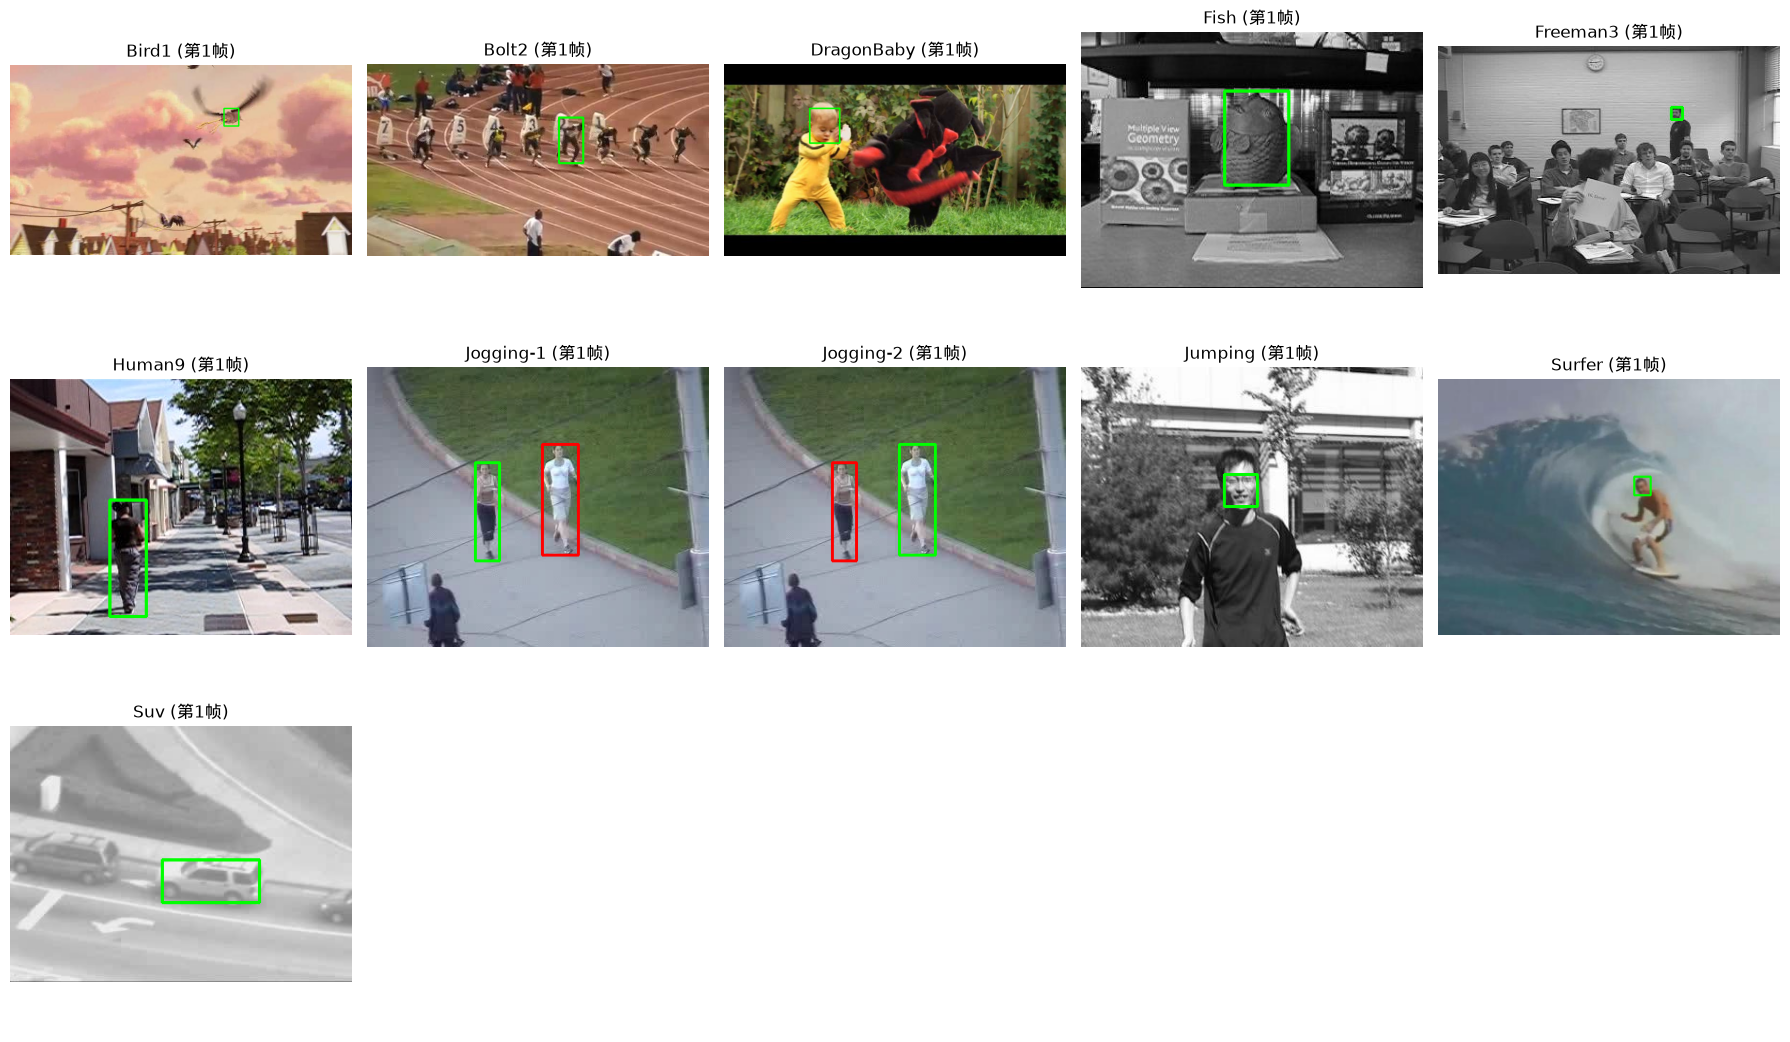

已保存: output/first_frames_gt.png


In [11]:
OTB_ROOT = Path("../data/OTB")
sequences = load_all_sequences(OTB_ROOT)
print(f"共加载 {len(sequences)} 条跟踪序列（Jogging 拆成 2 条）\n")
summary = sequence_summary(sequences)
print(summary.to_string(index=False))

seq = sequences["Suv"]
print("\n示例: Suv")
print("size     =", seq.size)
print("gt[0]    =", seq.get_gt(0))
print("frame0   =", seq.get_frame(0).shape, seq.get_frame(0).dtype)
print("frame473 =", seq.get_frame(473).shape)
print("gt[473]  =", seq.get_gt(473), " (有标注)")

freeman = sequences["Freeman3"]
print("Freeman3: 第 459 帧 gt =", freeman.get_gt(459))
print("Freeman3: 第 460 帧 gt =", freeman.get_gt(460), " (无标注，评测跳过)")

save_path = plot_first_frames(sequences)
print("已保存:", save_path)

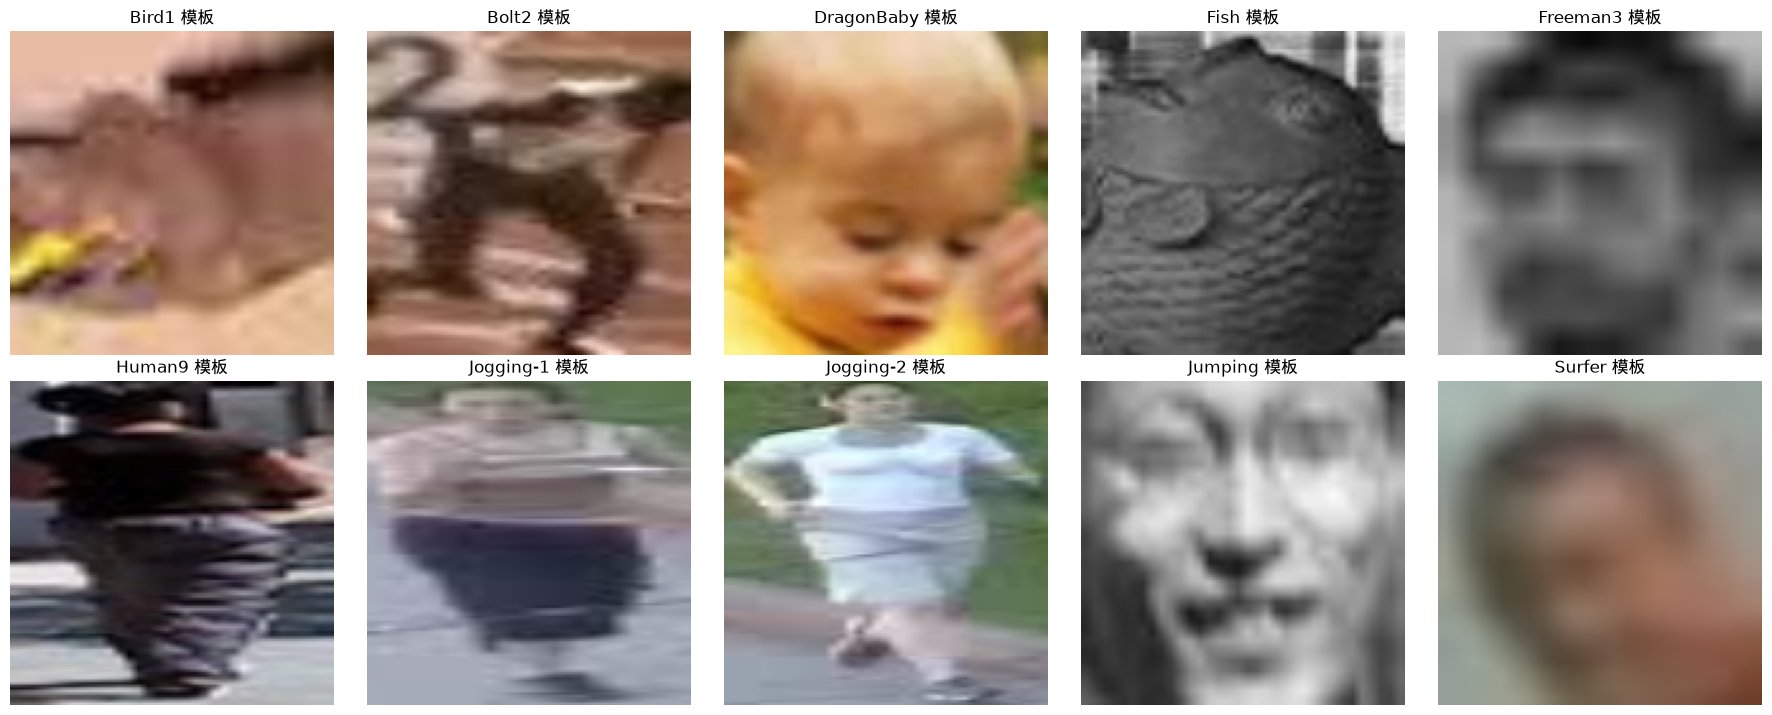

模板 patch  shape = (127, 127, 3)
搜索区域   shape = (255, 255, 3)
patch_to_tensor  = (3, 127, 127)


In [12]:
# 2.1 每个序列第 1 帧的模板 patch（127x127）
fig, axes = plt.subplots(2, 5, figsize=(18, 7.2))
for ax, name in zip(axes.ravel(), sorted(sequences)):
    seq = sequences[name]
    patch = crop_patch(seq.get_frame(0), seq.get_gt(0), (127, 127))
    ax.imshow(patch)
    ax.set_title(f"{name} 模板")
    ax.axis("off")
plt.tight_layout()
plt.show()

# 2.2 搜索区域示例：Suv 第 1 帧，以目标中心裁 255x255
seq = sequences["Suv"]
gt0 = seq.get_gt(0)
center = (gt0[0] + gt0[2] / 2, gt0[1] + gt0[3] / 2)
search = crop_centered(seq.get_frame(0), center, 255, (255, 255))
tpl = crop_patch(seq.get_frame(0), gt0, (127, 127))
print("模板 patch  shape =", tpl.shape)      # (127, 127, 3)
print("搜索区域   shape =", search.shape)    # (255, 255, 3)
print("patch_to_tensor  =", tuple(patch_to_tensor(tpl).shape))  # (3, 127, 127)

真值+5px噪声: DP@20px = 0.9989, Success AUC = 0.7214
整体右移30px: DP@20px = 0.0000, Success AUC = 0.5001


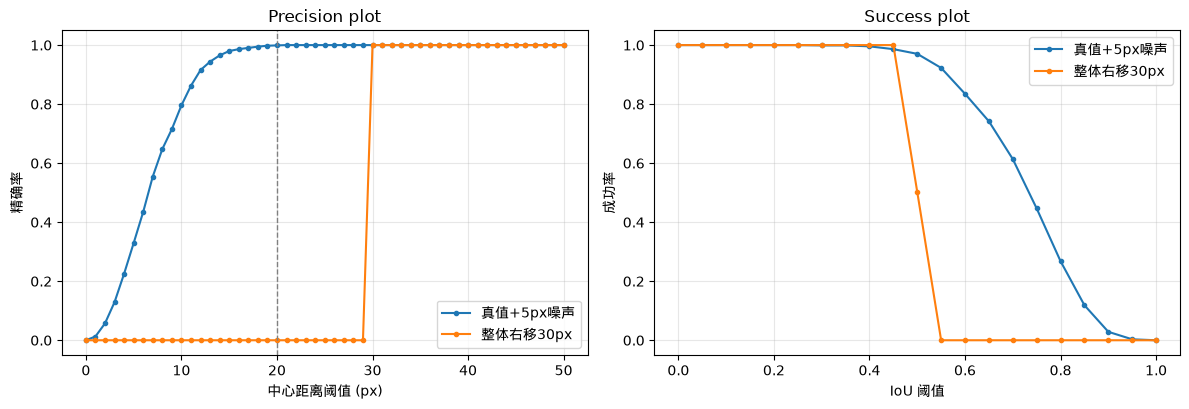

已保存: output/precision_success_demo.png


In [13]:
# 用两种"伪造预测"验证评测实现：5px 高斯噪声 vs 整体右移 30px
seq = sequences["Suv"]
gts = seq.gt.astype(np.float32)
rng = np.random.default_rng(0)

fake_preds = {
    "真值+5px噪声": gts + rng.normal(0, 5, gts.shape).astype(np.float32),
    "整体右移30px": gts + np.array([30.0, 0, 0, 0], dtype=np.float32),
}
results = {}
for name, preds in fake_preds.items():
    results[name] = evaluate_sequence(preds, gts)
    print(f"{name}: DP@20px = {results[name]['dp']:.4f}, Success AUC = {results[name]['auc']:.4f}")

# 画两条曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for name, res in results.items():
    axes[0].plot(res["thresholds_p"], res["precision"], marker=".", label=name)
    axes[1].plot(res["thresholds_s"], res["success"], marker=".", label=name)
axes[0].set_title("Precision plot")
axes[0].set_xlabel("中心距离阈值 (px)")
axes[0].set_ylabel("精确率")
axes[0].axvline(20, ls="--", c="gray", lw=1)
axes[1].set_title("Success plot")
axes[1].set_xlabel("IoU 阈值")
axes[1].set_ylabel("成功率")
for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()

output_dir = Path("output")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "precision_success_demo.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("已保存:", save_path)

template: (3, 127, 127) | searches: (12, 3, 255, 255) | disp: (12, 2)
region_size = 102.0 | search_scale = 2.5011 （原图搜索区域 -> 255px patch）
|dx| 均值 = 5.6  |dy| 均值 = 5.33


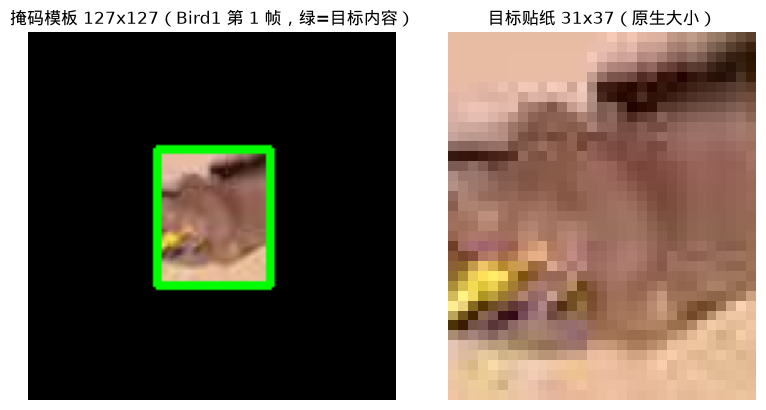

已保存: output/masked_template.png


In [14]:
torch.manual_seed(0)
demo_name = sorted(sequences)[0]
demo_seq = sequences[demo_name]
ds = TrackerSequenceDataset([demo_seq], bg_sequences=None,
                            num_trajectories=4, length=12, seq_len=None,
                            random_start=False, seed=0)
template, searches, disp, sample_scale = ds[0]
print("template:", tuple(template.shape), "| searches:", tuple(searches.shape),
      "| disp:", tuple(disp.shape))
print("region_size =", round(ds.region_size, 1),
      "| search_scale =", round(float(sample_scale), 4),
      "（原图搜索区域 -> 255px patch）")
print("|dx| 均值 =", round(disp[:, 0].abs().mean().item(), 2),
      " |dy| 均值 =", round(disp[:, 1].abs().mean().item(), 2))

# 图1: 掩码模板（背景置 0，绿框=目标框内容）+ 目标贴纸（粘贴用，原生大小）
fig, axes = plt.subplots(1, 2, figsize=(8, 4.2))
tpl_img = (template.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
axes[0].imshow(draw_box(tpl_img, ds.box_in_tpl, (0, 255, 0), 2))
axes[0].set_title(f"掩码模板 127x127（{demo_name} 第 1 帧，绿=目标内容）")
axes[0].axis("off")
axes[1].imshow(ds.sticker)
axes[1].set_title(f"目标贴纸 {ds.sticker.shape[1]}x{ds.sticker.shape[0]}（原生大小）")
axes[1].axis("off")
plt.tight_layout()

output_dir = Path("output")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "masked_template.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("已保存:", save_path)


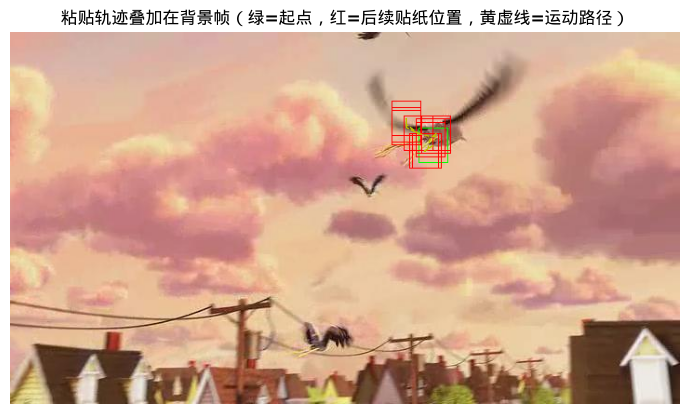

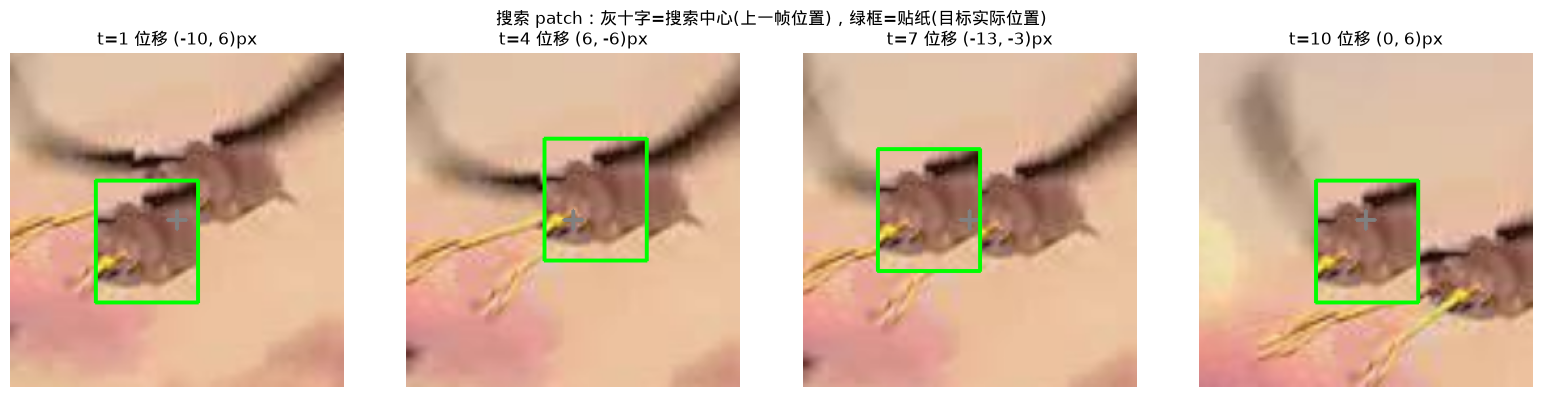

已保存: output/paste_trajectory.png, output/paste_search_patches.png


In [15]:
# 图2: 整条粘贴轨迹叠加在背景帧上（绿框=贴纸位置假设，黄虚线=运动路径）
trajectory0 = ds.trajectories[0][0]
centers = trajectory0[:, :2] + trajectory0[:, 2:] / 2
bw, bh = trajectory0[0, 2], trajectory0[0, 3]
bg_img = ds.bg_sequences[0].get_frame(0)  # 任务三合规：只使用第 1 帧背景
fig, ax = plt.subplots(figsize=(7, 5.4))
frame = bg_img.copy()
for i, box in enumerate(trajectory0):
    frame = draw_box(frame, box, (0, 255, 0) if i == 0 else (255, 0, 0), 1)
ax.plot(centers[:, 0], centers[:, 1], "y--", lw=1)
ax.imshow(frame)
ax.set_title("粘贴轨迹叠加在背景帧（绿=起点，红=后续贴纸位置，黄虚线=运动路径）")
ax.axis("off")
plt.tight_layout()

output_dir = Path("output")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "paste_trajectory.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

# 图3: 4 帧搜索 patch——贴纸恰在"中心 + disp"处（绿框），标签与内容自洽
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
half = ds.search_size / 2
for k, t in enumerate([0, 3, 6, 9]):
    d = centers[t + 1] - centers[t]
    patch = paste_sticker_on_bg(bg_img, centers[t], d, ds.sticker,
                               ds.region_size, ds.search_size)
    bw_patch, bh_patch = bw * ds.search_scale, bh * ds.search_scale
    box = (half + d[0] * ds.search_scale - bw_patch / 2,
           half + d[1] * ds.search_scale - bh_patch / 2,
           bw_patch, bh_patch)
    img = np.ascontiguousarray((patch_to_tensor(patch).permute(1, 2, 0).numpy() * 255).astype(np.uint8))
    img = cv2.drawMarker(img, (int(half), int(half)), (128, 128, 128),
                         cv2.MARKER_CROSS, markerSize=14, thickness=2)
    ax = axes[k]
    ax.imshow(draw_box(img, box, (0, 255, 0), 2))
    ax.set_title(f"t={t + 1} 位移 ({d[0]:.0f}, {d[1]:.0f})px")
    ax.axis("off")
plt.suptitle("搜索 patch：灰十字=搜索中心(上一帧位置)，绿框=贴纸(目标实际位置)", y=0.98)
plt.tight_layout()
save_path = output_dir / "paste_search_patches.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("已保存: output/paste_trajectory.png, output/paste_search_patches.png")


In [16]:
device = try_gpu()
print("device =", device)


device = cuda:0


In [17]:
if ALEXNET_WEIGHTS.exists():
    model = load_alexnet_weights(ALEXNET_WEIGHTS, device)
    model.eval()

    # 冒烟测试：随机输入过一遍前向
    x = torch.randn(1, 3, 227, 227, device=device)
    with torch.no_grad():
        y = model(x)
    print("前向输出 shape =", tuple(y.shape))  # (1, 1000)

    conv1 = model.features[0].weight
    print("conv1.weight   =", tuple(conv1.shape),
          f"mean={conv1.mean():.4f} std={conv1.std():.4f}")
    n_params = sum(p.numel() for p in model.parameters())
    print(f"总参数量 = {n_params / 1e6:.1f}M")
    print("权重加载与前向测试通过 ✔")
else:
    print("权重文件尚未下载，跳过测试。")
    print("请下载 alexnet-owt-7be5be79.pth 放到 model/ 后重新运行本 cell。")


前向输出 shape = (1, 1000)
conv1.weight   = (64, 3, 11, 11) mean=-0.0001 std=0.1170
总参数量 = 61.1M
权重加载与前向测试通过 ✔


In [18]:
# ===== 7.3 形状/梯度冒烟测试 =====
torch.manual_seed(0)  # 固定随机种子，保证可复现
encoder0 = make_alexnet_encoder(ALEXNET_WEIGHTS, device,
                                keep_pool2=False, keep_pool3=False)
tracker = SiameseTracker(encoder0, rnn_type="gru", hidden_size=128,
                         dropout=0.1, finetune_encoder=True).to(device)

n_total = sum(p.numel() for p in tracker.parameters())
n_train = sum(p.numel() for p in tracker.parameters() if p.requires_grad)
print(f"总参数量 = {n_total / 1e6:.2f}M | 可训练参数量 = {n_train / 1e6:.2f}M（编码器微调）")

template = torch.randn(2, 3, 127, 127, device=device)
searches = torch.randn(2, 8, 3, 255, 255, device=device)
pred, resp = tracker(template, searches, return_maps=True)
print("forward ->", tuple(pred.shape), "| maps ->", tuple(resp.shape))  # (2,8,2) (2,8,1,17,17)

# soft-argmax 读出自检：手工构造峰值在已知格位置的响应图，验证解码位移
with torch.no_grad():
    fake = torch.zeros(2, 4, 1, 17, 17, device=device)
    fake[..., 10, 5] = 1.0   # 峰值在格 (y=10, x=5) = 中心(8,8) 偏移 (+2格, -3格)
    d, c = tracker._soft_argmax_disp(fake)
    print(f"soft-argmax 解码 (dx, dy) = ({d[0, 0, 0]:.1f}, {d[0, 0, 1]:.1f}) px"
          f"（期望 -24.0, 16.0，scale=1.0）| 置信度 = {c[0, 0, 0]:.3f}")

# 混合损失（位移回归 + 响应图热图监督）梯度冒烟
disp_gt = torch.randn(2, 8, 2, device=device)
reg_loss = nn.SmoothL1Loss()(pred, disp_gt)
Hr, Wr = resp.shape[-2:]
target = gaussian_heatmap_target(disp_gt.reshape(-1, 2), (Hr, Wr),
                                 tracker.feat_stride,
                                 search_scale=tracker.search_scale)
map_loss = -(target * nnF.log_softmax(
    resp.reshape(-1, Hr * Wr), dim=1)).sum(dim=1).mean()
(reg_loss + map_loss).backward()
print(f"reg loss = {reg_loss.item():.4f} | map loss = {map_loss.item():.4f} | 联合 backward OK")

# rnn_type 可切换性（对比实验基座）：同一编码器权重，四种结构均可用
for rt in ["gru", "lstm", "rnn", "none"]:
    m = SiameseTracker(copy.deepcopy(encoder0), rnn_type=rt, hidden_size=64,
                       finetune_encoder=False,
                       template_size=127, search_size=255).to(device)
    with torch.no_grad():
        out = m(template, searches)
    print(f"rnn_type={rt:4s} -> {tuple(out.shape)}")

del encoder0, tracker, m


特征通道 C=256, 响应图 (17, 17), rnn_in_dim=291 (soft-argmax 2 + conf 1 + desc 288)
总参数量 = 2.65M | 可训练参数量 = 2.65M（编码器微调）
forward -> (2, 8, 2) | maps -> (2, 8, 1, 17, 17)
soft-argmax 解码 (dx, dy) = (-24.0, 16.0) px（期望 -24.0, 16.0，scale=1.0）| 置信度 = 1.000
reg loss = 24.3227 | map loss = 8.0108 | 联合 backward OK
特征通道 C=256, 响应图 (17, 17), rnn_in_dim=291 (soft-argmax 2 + conf 1 + desc 288)
rnn_type=gru  -> (2, 8, 2)
特征通道 C=256, 响应图 (17, 17), rnn_in_dim=291 (soft-argmax 2 + conf 1 + desc 288)
rnn_type=lstm -> (2, 8, 2)
特征通道 C=256, 响应图 (17, 17), rnn_in_dim=291 (soft-argmax 2 + conf 1 + desc 288)
rnn_type=rnn  -> (2, 8, 2)
特征通道 C=256, 响应图 (17, 17), rnn_in_dim=291 (soft-argmax 2 + conf 1 + desc 288)
rnn_type=none -> (2, 8, 2)


### 8.训练数据（截断 BPTT 窗口）、训练方法与 Baseline 配置

* `TrackerSequenceDataset`（定义见第 4 节）：多目标掩码模板 + 自视频背景贴纸粘贴，每次返回一个**窗口**样本：
  * `template`(3,127,127)：第 1 帧目标框内容、按目标上下文区域缩放，背景置 0
  * `searches`(L,3,255,255)：按同一上下文比例裁搜索区域并缩放，贴纸粘贴在
    "中心 + disp" 处——L 步标签与图像内容**严格自洽**（第 1 帧 disp=0）
  * `disp`(L,2)：相邻帧中心位移（原图像素）；另返回每个目标的 `search_scale`
  * `seq_len` 即截断 BPTT 窗口长度；`random_start=True` 每轮随机采样窗口起点
* 运动幅度：max_step=0.5×min(宽,高)、momentum=0.5、max_drift=1.5×min(宽,高)，
  逐帧位移按 `8/search_scale` 原图像素量化，使缩放后对齐 8px 特征格，
  且贴纸完整落在搜索 patch 内
* 训练和验证均覆盖全部目标序列；每个目标使用自己的视频背景，并分别生成相同数量的轨迹
* `train_tracker`：通用训练循环（实验四风格）
  * 损失 = SmoothL1 位移回归 + `heatmap_weight` × 响应图交叉熵（soft 目标为以真实
    位移为中心的高斯分布）；`heatmap_weight=0` 可退回纯回归（消融实验）
  * Adam + 梯度裁剪；早停（patience）+ 最佳权重恢复；返回 history 供画图/对比表
  * 验证：teacher-forcing 整条轨迹前向，记录 val loss、平均位移误差(px) 与**零预测基线**对照
* Baseline 配置见下：**端到端微调编码器**（lr 分层：编码器 1e-4 / 其余 1e-3）；
  训练 cell 在最后一格，（预计 GPU 2~5 分钟），执行前先跑通前面所有 cell


贴纸轨迹参数: {'momentum': 0.5, 'spring': 0.02}
目标序列（每条均使用第 1 帧）: ['Bird1', 'Bolt2', 'DragonBaby', 'Fish', 'Freeman3', 'Human9', 'Jogging-1', 'Jogging-2', 'Jumping', 'Surfer', 'Suv']
每个目标的背景: 只使用对应视频第 1 帧（任务三合规模式）
template: (3, 127, 127) | searches: (32, 3, 255, 255) | disp: (32, 2)
窗口内 |dx| 均值 = 7.25  |dy| 均值 = 7.18
region_size = 102.0 | search_scale = 2.5011 （该目标：图像px -> 搜索patch px）
训练样本数 = 176 = 11 个目标 × 16 条轨迹
验证样本数 = 44 = 11 个目标 × 4 条轨迹


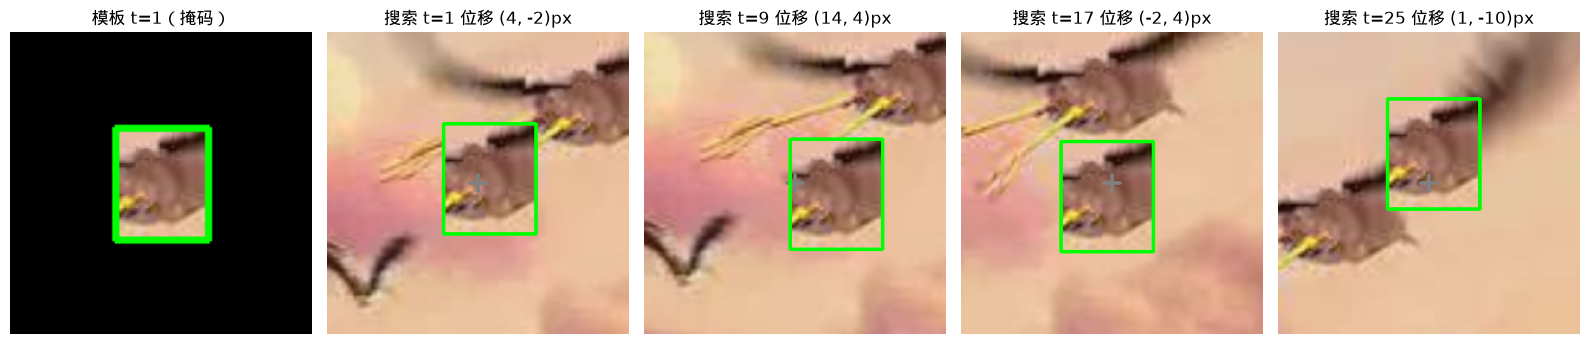

已保存: output/tracker_input_demo.png


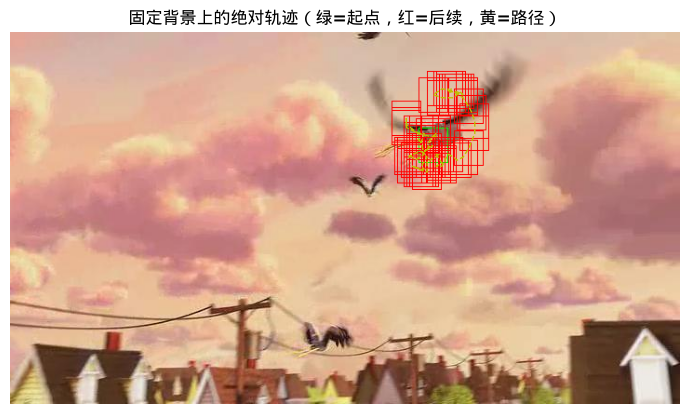

已保存: output/tracker_absolute_trajectory_demo.png


In [19]:
# ===== 8.1 Baseline 训练数据装配（掩码模板 + 贴纸粘贴，截断 BPTT 窗口） =====
torch.manual_seed(0)
TARGET_NAMES = sorted(sequences)
TARGET_SEQS = [sequences[n] for n in TARGET_NAMES]
traj_kwargs = dict(momentum=0.5, spring=0.02)
print("贴纸轨迹参数:", {k: round(float(v), 2) for k, v in traj_kwargs.items()})

print("目标序列（每条均使用第 1 帧）:", TARGET_NAMES)
print("每个目标的背景: 只使用对应视频第 1 帧（任务三合规模式）")

train_ds = TrackerSequenceDataset(
    TARGET_SEQS, bg_sequences=None, num_trajectories=16,
    length=60, seq_len=32, random_start=True, seed=0,
    traj_kwargs=traj_kwargs, background_frame_mode="first_frame_only",
    center_jitter_std=6.0, max_center_jitter=12.0)
val_ds = TrackerSequenceDataset(
    TARGET_SEQS, bg_sequences=None, num_trajectories=4,
    length=60, seq_len=None, random_start=False, seed=999,
    traj_kwargs=traj_kwargs, background_frame_mode="first_frame_only",
    center_jitter_std=6.0, max_center_jitter=12.0)
template, searches, disp, sample_scale = train_ds[0]
print("template:", tuple(template.shape), "| searches:", tuple(searches.shape),
      "| disp:", tuple(disp.shape))
print("窗口内 |dx| 均值 =", round(disp[:, 0].abs().mean().item(), 2),
      " |dy| 均值 =", round(disp[:, 1].abs().mean().item(), 2))
print("region_size =", round(train_ds.region_size, 1),
      "| search_scale =", round(float(sample_scale), 4),
      "（该目标：图像px -> 搜索patch px）")
print(f"训练样本数 = {len(train_ds)} = {len(TARGET_SEQS)} 个目标 × "
      f"{train_ds.num_trajectories} 条轨迹")
print(f"验证样本数 = {len(val_ds)} = {len(TARGET_SEQS)} 个目标 × "
      f"{val_ds.num_trajectories} 条轨迹")

# 可视化：模板 + 4 帧搜索 patch（灰十字=搜索中心，绿框=贴纸=目标实际位置）
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6))
bw = round(train_ds.sticker.shape[1] * float(sample_scale))
bh = round(train_ds.sticker.shape[0] * float(sample_scale))


def _show_patch(ax, patch, box, title, show_center=False):
    img = np.ascontiguousarray(
        (patch.permute(1, 2, 0).numpy() * 255).astype(np.uint8))
    half = img.shape[0] // 2
    if show_center:
        img = cv2.drawMarker(img, (half, half), (128, 128, 128),
                             cv2.MARKER_CROSS, markerSize=14, thickness=2)
    ax.imshow(draw_box(img, box, (0, 255, 0), 2))
    ax.set_title(title)
    ax.axis("off")


_show_patch(axes[0], template, train_ds.box_in_tpl, "模板 t=1（掩码）")
half = train_ds.search_size / 2
for k, t in enumerate([0, 8, 16, 24]):
    box = (half + disp[t, 0].item() * float(sample_scale) - bw / 2,
           half + disp[t, 1].item() * float(sample_scale) - bh / 2, bw, bh)
    _show_patch(axes[k + 1], searches[t],
                box, f"搜索 t={t + 1} 位移 ({disp[t, 0]:.0f}, {disp[t, 1]:.0f})px",
                show_center=True)
plt.tight_layout()
output_dir = Path("output")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "tracker_input_demo.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("已保存:", save_path)

# 固定背景上的绝对轨迹：这里才展示目标在画布中的完整运动路径
trajectory0 = train_ds.trajectories[0][0]
centers0 = trajectory0[:, :2] + trajectory0[:, 2:] / 2
bg0 = train_ds.bg_sequences[0].get_frame(
    0)
frame0 = bg0.copy()
for i, box in enumerate(trajectory0):
    frame0 = draw_box(frame0, box,
                      (0, 255, 0) if i == 0 else (255, 0, 0), 1)
fig, ax = plt.subplots(figsize=(7, 5.4))
ax.imshow(frame0)
ax.plot(centers0[:, 0], centers0[:, 1], "y--", lw=1)
ax.set_title("固定背景上的绝对轨迹（绿=起点，红=后续，黄=路径）")
ax.axis("off")
plt.tight_layout()
trajectory_path = output_dir / "tracker_absolute_trajectory_demo.png"
fig.savefig(trajectory_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("已保存:", trajectory_path)


In [20]:
def train_tracker(model, train_loader, val_loader, loss_fn, optimizer,
                  num_epochs, device, patience=8, min_delta=1e-4,
                  restore_best=True, grad_clip=1.0,
                  heatmap_weight=1.0, map_sigma=1.0):
    """训练 SiameseTracker（SiamFC 式响应图监督 + 位移回归 + 截断 BPTT）。

    每 batch: (template, searches, disp, search_scale)；模型输出 (B, T, 2)，T 步全有标签。
    损失 = SmoothL1 位移回归 + heatmap_weight × 响应图交叉熵：
      模型位移输出 = 响应图 soft-argmax 解码 + RNN/MLP 残差，回归损失直接监督解码；
      响应图交叉熵让归一化响应图逼近"以真实位移为中心"的归一化高斯分布
      （SiamFC 式定位监督），heatmap_weight=0 时退化为纯 soft-argmax 回归。
    验证: teacher-forcing 整条轨迹前向，记录 val loss、平均位移误差(px) 与 map loss。
    patience > 0 时早停并恢复最佳权重；grad_clip 为梯度裁剪范数（None 关闭）。
    返回 history: {train_loss, val_loss, val_disp_err, train_map_loss, val_map_loss,
                   best_epoch, best_val_loss}
    """
    model.to(device)
    history = {"train_loss": [], "val_loss": [], "val_disp_err": [],
               "train_map_loss": [], "val_map_loss": []}
    best_loss, best_state, best_epoch, bad_epochs = float("inf"), None, 0, 0

    for epoch in range(num_epochs):
        model.train()
        train_sum = train_cnt = 0.0
        train_map_sum = 0.0
        for template, searches, disp, search_scale in train_loader:
            template = template.to(device)
            searches = searches.to(device)
            disp = disp.to(device)
            search_scale = search_scale.to(device)

            optimizer.zero_grad()
            pred, resp = model(template, searches, search_scale=search_scale,
                               return_maps=True)  # (B,T,2),(B,T,1,Hr,Wr)
            reg_loss = loss_fn(pred, disp)
            Hr, Wr = resp.shape[-2:]
            target = gaussian_heatmap_target(
                disp.reshape(-1, 2), (Hr, Wr), model.feat_stride, map_sigma,
                search_scale)
            map_loss = -(target * nnF.log_softmax(
                resp.reshape(-1, Hr * Wr), dim=1)).sum(dim=1).mean()
            loss = reg_loss + heatmap_weight * map_loss
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            n = disp.shape[0]
            train_sum += loss.item() * n
            train_map_sum += map_loss.item() * n
            train_cnt += n

        model.eval()
        val_sum = val_err = val_cnt = 0.0
        val_map_sum = 0.0
        with torch.no_grad():
            for template, searches, disp, search_scale in val_loader:
                template = template.to(device)
                searches = searches.to(device)
                disp = disp.to(device)
                search_scale = search_scale.to(device)
                pred, resp = model(template, searches, search_scale=search_scale,
                                   return_maps=True)
                reg_loss = loss_fn(pred, disp)
                Hr, Wr = resp.shape[-2:]
                target = gaussian_heatmap_target(
                    disp.reshape(-1, 2), (Hr, Wr), model.feat_stride, map_sigma,
                    search_scale)
                map_loss = -(target * nnF.log_softmax(
                    resp.reshape(-1, Hr * Wr), dim=1)).sum(dim=1).mean()
                val_sum += (reg_loss + heatmap_weight * map_loss).item() * disp.shape[0]
                val_err += (pred - disp).abs().mean(dim=(1, 2)).sum().item()
                val_map_sum += map_loss.item() * disp.shape[0]
                val_cnt += disp.shape[0]
        val_loss = val_sum / val_cnt
        val_err = val_err / val_cnt
        val_map = val_map_sum / val_cnt

        history["train_loss"].append(train_sum / train_cnt)
        history["val_loss"].append(val_loss)
        history["val_disp_err"].append(val_err)
        history["train_map_loss"].append(train_map_sum / train_cnt)
        history["val_map_loss"].append(val_map)

        if patience > 0:
            if val_loss < best_loss - min_delta:
                best_loss, best_epoch, bad_epochs = val_loss, epoch + 1, 0
                if restore_best:
                    best_state = copy.deepcopy(model.state_dict())
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    print(f"early stop at epoch {epoch + 1} | "
                          f"best epoch {best_epoch} | best val loss {best_loss:.4f}")
                    break

        print(f"epoch {epoch + 1:03d} | train loss {history['train_loss'][-1]:.4f} "
              f"(map {history['train_map_loss'][-1]:.3f}) | "
              f"val loss {val_loss:.4f} (map {val_map:.3f}) | "
              f"val disp err {val_err:.3f} px")

    if restore_best and best_state is not None:
        model.load_state_dict(best_state)
        print(f"恢复最佳权重 (epoch {best_epoch}, val loss {best_loss:.4f})")
    history["best_epoch"] = best_epoch
    history["best_val_loss"] = best_loss
    return history


def plot_loss_curve(history, fig_name, output_dir="./output"):
    """绘制训练/验证 loss 曲线并保存。"""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history["train_loss"], marker=".", label="train loss")
    ax.plot(history["val_loss"], marker=".", label="val loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss (回归 + 热图监督)")
    ax.set_title(f"训练曲线: {fig_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_path = output_dir / f"loss_{fig_name}.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return save_path


### 8.2.1 第一轮训练诊断（记录）与数据方案修正

第一轮 baseline（GRU, seq_len=32, 30 epochs）实测结果：

| 指标 | 现象 | 结论 |
|---|---|---|
| 响应图交叉熵 map loss | 3963 -> ~4.4 | 响应图在"变整齐"，但峰值位置学不到目标 |
| val disp err | 始终 ~8.5px ≈ 零预测基线 8.499px | 定位完全失效，位移头学输出 0 |

**根因（已用像素级匹配验证）：训练标签与图像内容脱节 + 模板被背景主导。**

1. **合成轨迹不跟随真实目标**：合成轨迹只是运动假设，在目标视频里按轨迹裁剪的
   patch 中，"中心 + disp" 处并没有目标（如 Suv 第 1 帧：真实小车中心在 (124,128)，
   轨迹标注位置却在 (119,145)，偏差 18px）。响应图没有可监督的视觉信号，
   模型只能学输出 0（零梯度鞍点）。
2. **模板含大量静态背景**：127px 模板里目标仅占约 91×40，道路等背景结构主导互相关峰；
   即使改用真实 gt 轨迹，原始互相关响应图 argmax 也不跟随目标（conv1~conv5 皆如此）。

**修复（已验证）**：改为**多目标掩码模板 + 自视频背景贴纸粘贴**（见第 4 节）：
模板只保留目标框内容（背景置 0），搜索 patch 在"中心 + disp"处粘贴目标贴纸，
标签与图像内容严格自洽；位移量化到 8px 特征格 + 网格对齐锚点 + 背景反射填充，
冻结编码器验证：验证集响应图 argmax 命中率 99.8%（训练集约 4% 干扰帧由微调纠正）。
模型只需学会读出峰值 + 时序平滑，"位移头恒 0"的坍缩不会出现；
gru/lstm/rnn/none 对比实验保留，差异主要体现在真实序列滚动跟踪的稳定性上（见 8.6）。


In [21]:
# ===== 8.3 Baseline 配置（只定义与装载，不训练；训练在下一格） =====
BASELINE_CONFIG = {
    "target_names": TARGET_NAMES,
    "background_mode": "first_frame_only",
    "center_jitter_std": 6.0,
    "max_center_jitter": 12.0,
    "confidence_threshold": 0.12,
    "recovery_threshold": 0.10,
    "recovery_scale": 1.5,
    "max_step_factor": 0.5,
    "num_trajectories": 16,          # 每个目标序列相同数量
    "val_trajectories": 4,            # 每个目标序列相同数量
    "length": 60,
    "seq_len": 32,
    "random_start": True,
    "rnn_type": "gru",
    "hidden_size": 128,
    "num_layers": 1,
    "dropout": 0.1,
    "desc_channels": 32,
    "finetune_encoder": True,
    "heatmap_weight": 1.0,
    "map_sigma": 1.0,
    "map_temperature": 1.0,
    "batch_size": 8,
    "lr_head": 1e-3,
    "lr_encoder": 1e-4,
    "num_epochs": 30,
    "patience": 8,
    "grad_clip": 1.0,
    "seed": 0,
}
BASELINE_CONFIG["traj_kwargs"] = dict(momentum=0.5, spring=0.02)
print("Baseline 配置:")
for k, v in BASELINE_CONFIG.items():
    print(f"  {k:18s} = {v}")

torch.manual_seed(BASELINE_CONFIG["seed"])
train_ds = TrackerSequenceDataset(
    TARGET_SEQS, bg_sequences=None,
    num_trajectories=BASELINE_CONFIG["num_trajectories"],
    length=BASELINE_CONFIG["length"],
    seq_len=BASELINE_CONFIG["seq_len"], random_start=True,
    seed=0, traj_kwargs=BASELINE_CONFIG["traj_kwargs"],
    background_frame_mode=BASELINE_CONFIG["background_mode"],
    center_jitter_std=BASELINE_CONFIG["center_jitter_std"],
    max_center_jitter=BASELINE_CONFIG["max_center_jitter"])
val_ds = TrackerSequenceDataset(
    TARGET_SEQS, bg_sequences=None,
    num_trajectories=BASELINE_CONFIG["val_trajectories"],
    length=BASELINE_CONFIG["length"], seq_len=None,
    random_start=False, seed=999,
    traj_kwargs=BASELINE_CONFIG["traj_kwargs"],
    background_frame_mode=BASELINE_CONFIG["background_mode"],
    center_jitter_std=BASELINE_CONFIG["center_jitter_std"],
    max_center_jitter=BASELINE_CONFIG["max_center_jitter"])
print("search_scale 示例 =", round(train_ds.search_scale, 4),
      "（不同目标各自计算，batch 中按样本传入）")
train_loader = DataLoader(train_ds, batch_size=BASELINE_CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BASELINE_CONFIG["batch_size"], shuffle=False)

# 零预测基线：恒输出 0 位移时的平均误差（模型至少应明显低于它）
zero_err = 0.0
zero_n = 0
with torch.no_grad():
    for _, _, disp, _ in val_loader:
        zero_err += disp.abs().mean().item() * disp.shape[0]
        zero_n += disp.shape[0]
zero_err /= zero_n
print(f"零预测基线（恒输出 0 位移）平均误差 = {zero_err:.3f} px")

model = SiameseTracker(
    make_alexnet_encoder(ALEXNET_WEIGHTS, device,
                         keep_pool2=False, keep_pool3=False),
    rnn_type=BASELINE_CONFIG["rnn_type"],
    hidden_size=BASELINE_CONFIG["hidden_size"],
    num_layers=BASELINE_CONFIG["num_layers"],
    dropout=BASELINE_CONFIG["dropout"],
    desc_channels=BASELINE_CONFIG["desc_channels"],
    finetune_encoder=BASELINE_CONFIG["finetune_encoder"],
    map_temperature=BASELINE_CONFIG["map_temperature"],
).to(device)
# 分层学习率：预训练编码器小步长微调，RNN/头正常学习率
optimizer = torch.optim.Adam([
    {"params": model.encoder.parameters(), "lr": BASELINE_CONFIG["lr_encoder"]},
    {"params": [p for n, p in model.named_parameters()
                if p.requires_grad and not n.startswith("encoder.")],
     "lr": BASELINE_CONFIG["lr_head"]},
])
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"可训练参数量 = {n_train / 1e6:.2f}M（端到端微调）")


Baseline 配置:
  target_names       = ['Bird1', 'Bolt2', 'DragonBaby', 'Fish', 'Freeman3', 'Human9', 'Jogging-1', 'Jogging-2', 'Jumping', 'Surfer', 'Suv']
  background_mode    = first_frame_only
  center_jitter_std  = 6.0
  max_center_jitter  = 12.0
  confidence_threshold = 0.12
  recovery_threshold = 0.1
  recovery_scale     = 1.5
  max_step_factor    = 0.5
  num_trajectories   = 16
  val_trajectories   = 4
  length             = 60
  seq_len            = 32
  random_start       = True
  rnn_type           = gru
  hidden_size        = 128
  num_layers         = 1
  dropout            = 0.1
  desc_channels      = 32
  finetune_encoder   = True
  heatmap_weight     = 1.0
  map_sigma          = 1.0
  map_temperature    = 1.0
  batch_size         = 8
  lr_head            = 0.001
  lr_encoder         = 0.0001
  num_epochs         = 30
  patience           = 8
  grad_clip          = 1.0
  seed               = 0
  traj_kwargs        = {'momentum': 0.5, 'spring': 0.02}
search_scale 示例 = 2.5011 

epoch 001 | train loss 6.5114 (map 3.819) | val loss 4.6602 (map 3.260) | val disp err 1.807 px
epoch 002 | train loss 3.9033 (map 3.185) | val loss 3.7046 (map 3.177) | val disp err 0.880 px
epoch 003 | train loss 3.5119 (map 3.143) | val loss 3.4468 (map 3.142) | val disp err 0.613 px
epoch 004 | train loss 3.4032 (map 3.116) | val loss 3.3500 (map 3.110) | val disp err 0.521 px
epoch 005 | train loss 3.3630 (map 3.095) | val loss 3.3423 (map 3.086) | val disp err 0.572 px
epoch 006 | train loss 3.3098 (map 3.080) | val loss 3.3307 (map 3.086) | val disp err 0.532 px
epoch 007 | train loss 3.2904 (map 3.076) | val loss 3.2805 (map 3.074) | val disp err 0.479 px
epoch 008 | train loss 3.2446 (map 3.063) | val loss 3.2409 (map 3.064) | val disp err 0.440 px
epoch 009 | train loss 3.2272 (map 3.057) | val loss 3.2202 (map 3.054) | val disp err 0.421 px
epoch 010 | train loss 3.2134 (map 3.048) | val loss 3.1875 (map 3.053) | val disp err 0.390 px
epoch 011 | train loss 3.2080 (map 3.047

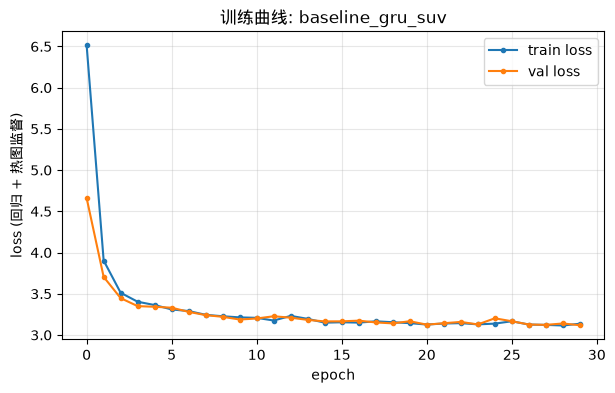

已保存: /home/experiments/M502019B/5-final/output/tracker_baseline_gru_suv.pt
best epoch = 30 | best val loss = 3.1184
模型最佳平均位移误差 = 0.327 px（零预测基线 7.535 px）


In [22]:
# ===== 8.4 训练 Baseline（预计 GPU 2~5 分钟，本 cell 由你手动执行） =====
history = train_tracker(model, train_loader, val_loader, nn.SmoothL1Loss(),
                        optimizer, num_epochs=BASELINE_CONFIG["num_epochs"],
                        device=device, patience=BASELINE_CONFIG["patience"],
                        grad_clip=BASELINE_CONFIG["grad_clip"],
                        heatmap_weight=BASELINE_CONFIG["heatmap_weight"],
                        map_sigma=BASELINE_CONFIG["map_sigma"])
plot_loss_curve(history, "baseline_gru_suv")
save_tracker(model, output_dir / "tracker_baseline_gru_suv.pt")
best_err = min(history["val_disp_err"])
print(f"best epoch = {history['best_epoch']} | best val loss = {history['best_val_loss']:.4f}")
print(f"模型最佳平均位移误差 = {best_err:.3f} px（零预测基线 {zero_err:.3f} px）")


特征通道 C=256, 响应图 (17, 17), rnn_in_dim=291 (soft-argmax 2 + conf 1 + desc 288)
最终位移误差 (soft-argmax + RNN 残差) = 0.327 px
纯响应图 soft-argmax 解码误差        = 1.334 px
响应图 argmax 峰值格误差            = 1.159 px（零基线 7.535 px）
平均峰值置信度 = 0.167
逐帧误差: 均值 0.33 | 中位 0.27 | p90 0.66 | 最大 4.10 px


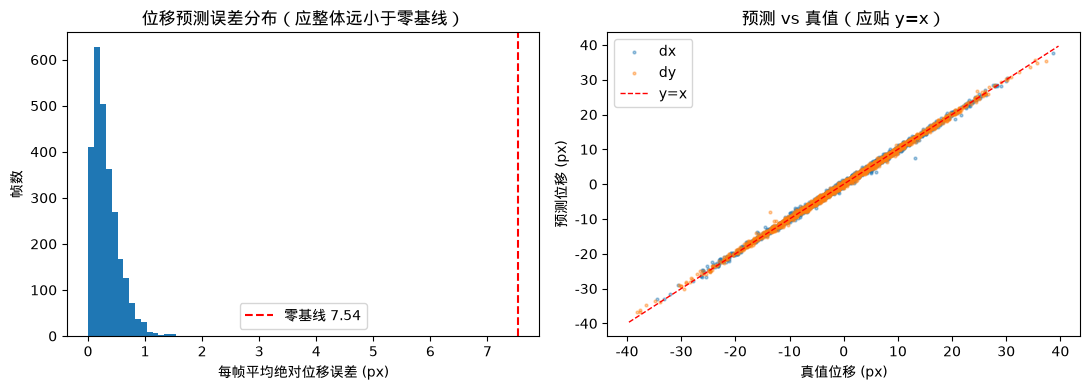

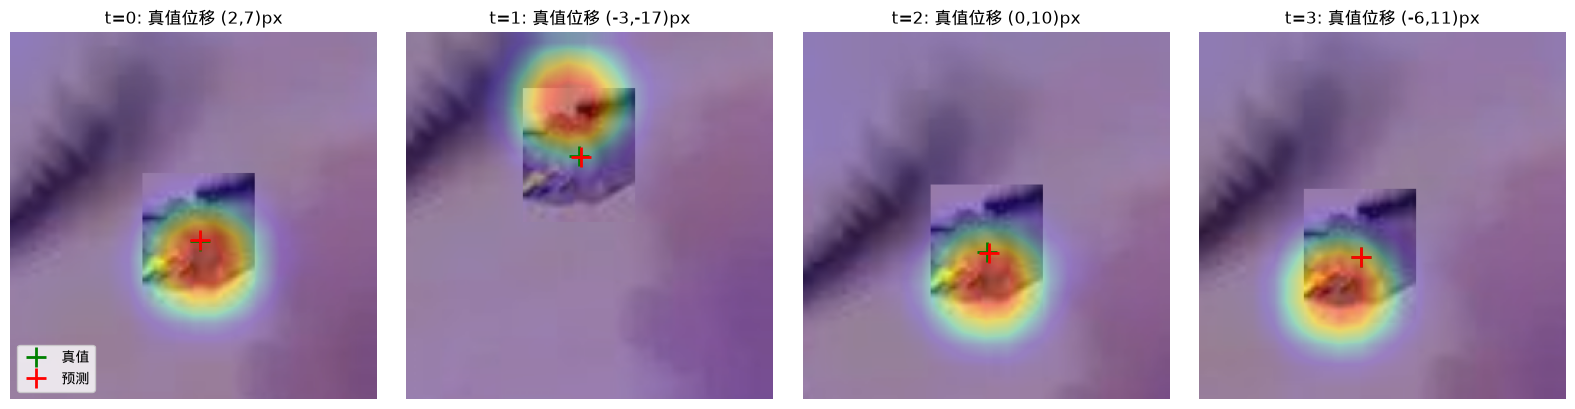

In [23]:
# ===== 8.5 训练后诊断：响应图定位 vs 位移读出（只做前向，不训练） =====
# 先运行 cell 8.4 重新训练（旧 checkpoint 是旧架构，无法加载），再执行本 cell。
# 回答三个问题:
#   1) 纯响应图 soft-argmax 解码（SiamFC 式读出）误差是否远低于零基线；
#   2) 加上 RNN 残差后的最终误差；逐帧误差分布是否还有"输出恒 0"的样本簇；
#   3) 响应图 argmax 峰值格是否对准真值位移格。
diag = SiameseTracker(
    make_alexnet_encoder(ALEXNET_WEIGHTS, device,
                         keep_pool2=False, keep_pool3=False),
    rnn_type=BASELINE_CONFIG["rnn_type"],
    hidden_size=BASELINE_CONFIG["hidden_size"],
    num_layers=BASELINE_CONFIG["num_layers"],
    dropout=BASELINE_CONFIG["dropout"],
    desc_channels=BASELINE_CONFIG["desc_channels"],
    finetune_encoder=BASELINE_CONFIG["finetune_encoder"],
    map_temperature=BASELINE_CONFIG["map_temperature"],
).to(device)
try:
    load_tracker(diag, output_dir / "tracker_baseline_gru_suv.pt", device)
except RuntimeError as e:
    raise RuntimeError(
        "checkpoint 与当前模型结构不匹配（旧架构或未训练）。"
        "请先运行 8.4 训练 cell 生成新权重后再执行本 cell。") from e
diag.eval()

final_err, decode_err, peak_err, confs = [], [], [], []
pred_frames, disp_frames = [], []
with torch.no_grad():
    for template, searches, disp, search_scale in val_loader:
        template = template.to(device)
        searches = searches.to(device)
        disp = disp.to(device)
        search_scale = search_scale.to(device)
        pred, resp = diag(template, searches, search_scale=search_scale,
                          return_maps=True)   # (B,T,2),(B,T,1,Hr,Wr)
        Hr, Wr = resp.shape[-2:]
        disp_dec, conf = diag._soft_argmax_disp(resp, search_scale)  # 纯响应图解码
        final_err.append((pred - disp).abs().mean(dim=(1, 2)))
        decode_err.append((disp_dec - disp).abs().mean(dim=(1, 2)))
        confs.append(conf.squeeze(-1).mean(dim=1))
        # 响应图 argmax 格 vs 高斯目标峰值格（换算像素）
        tgt = gaussian_heatmap_target(disp.reshape(-1, 2), (Hr, Wr),
                                      diag.feat_stride, 1.0, search_scale)
        tgt_peak = tgt.reshape(-1, Hr * Wr).argmax(dim=-1)
        map_peak = resp.reshape(-1, Hr * Wr).argmax(dim=-1)
        ty, tx = tgt_peak // Wr, tgt_peak % Wr
        my, mx = map_peak // Wr, map_peak % Wr
        peak_err.append(((ty - my) ** 2 + (tx - mx) ** 2).float().sqrt()
                        .reshape(disp.shape[0], -1).mean(dim=1) * diag.feat_stride)
        pred_frames.append(pred.reshape(-1, 2))
        disp_frames.append(disp.reshape(-1, 2))

final_err = torch.cat(final_err)
decode_err = torch.cat(decode_err)
peak_err = torch.cat(peak_err)
confs = torch.cat(confs)
pred_all = torch.cat(pred_frames)
disp_all = torch.cat(disp_frames)
print(f"最终位移误差 (soft-argmax + RNN 残差) = {final_err.mean():.3f} px")
print(f"纯响应图 soft-argmax 解码误差        = {decode_err.mean():.3f} px")
print(f"响应图 argmax 峰值格误差            = {peak_err.mean():.3f} px（零基线 {zero_err:.3f} px）")
print(f"平均峰值置信度 = {confs.mean():.3f}")

err = (pred_all - disp_all).abs().mean(dim=1)
print(f"逐帧误差: 均值 {err.mean():.2f} | 中位 {err.median():.2f} | "
      f"p90 {err.quantile(0.9):.2f} | 最大 {err.max():.2f} px")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(err.cpu().numpy(), bins=40)
axes[0].axvline(zero_err, color="r", ls="--", label=f"零基线 {zero_err:.2f}")
axes[0].set_xlabel("每帧平均绝对位移误差 (px)")
axes[0].set_ylabel("帧数")
axes[0].set_title("位移预测误差分布（应整体远小于零基线）")
axes[0].legend()
axes[1].scatter(disp_all[:, 0].cpu(), pred_all[:, 0].cpu(), s=4, alpha=0.4, label="dx")
axes[1].scatter(disp_all[:, 1].cpu(), pred_all[:, 1].cpu(), s=4, alpha=0.4, label="dy")
lim = max(disp_all.abs().max().item(), pred_all.abs().max().item()) + 1
axes[1].plot([-lim, lim], [-lim, lim], "r--", lw=1, label="y=x")
axes[1].set_xlabel("真值位移 (px)")
axes[1].set_ylabel("预测位移 (px)")
axes[1].set_title("预测 vs 真值（应贴 y=x）")
axes[1].legend()
plt.tight_layout()
plt.show()

# 响应图可视化: 第一条 val 轨迹前 4 帧（搜索 patch + 热力图 + 真值/预测标记）
template0, searches0, disp0, sample_scale0 = val_ds[0]
with torch.no_grad():
    pred0, resp0 = diag(template0.unsqueeze(0).to(device),
                        searches0.unsqueeze(0).to(device),
                        search_scale=sample_scale0.unsqueeze(0).to(device),
                        return_maps=True)
resp0 = resp0[0, :, 0].cpu().numpy()   # (T,17,17)
s = float(sample_scale0)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for t in range(4):
    ax = axes[t]
    patch = searches0[t].permute(1, 2, 0).numpy()
    ax.imshow(patch)
    hm = cv2.resize(resp0[t], (patch.shape[1], patch.shape[0]),
                    interpolation=cv2.INTER_LINEAR)
    ax.imshow(hm, cmap="jet", alpha=0.35)
    true_xy = (127.5 + disp0[t, 0].item() * s, 127.5 + disp0[t, 1].item() * s)
    pred_xy = (127.5 + pred0[0, t, 0].item() * s, 127.5 + pred0[0, t, 1].item() * s)
    ax.plot(*true_xy, "g+", ms=14, mew=2, label="真值")
    ax.plot(*pred_xy, "r+", ms=14, mew=2, label="预测")
    ax.set_title(f"t={t}: 真值位移 ({disp0[t, 0]:.0f},{disp0[t, 1]:.0f})px")
    ax.axis("off")
axes[0].legend(loc="lower left")
plt.tight_layout()
plt.show()

特征通道 C=256, 响应图 (17, 17), rnn_in_dim=291 (soft-argmax 2 + conf 1 + desc 288)
Suv 滚动跟踪: DP@20px = 0.934 | Success AUC = 0.773 | 平均中心误差 = 7.1 px
对照（停在初始位置不动）: 平均中心误差 = 62.4 px


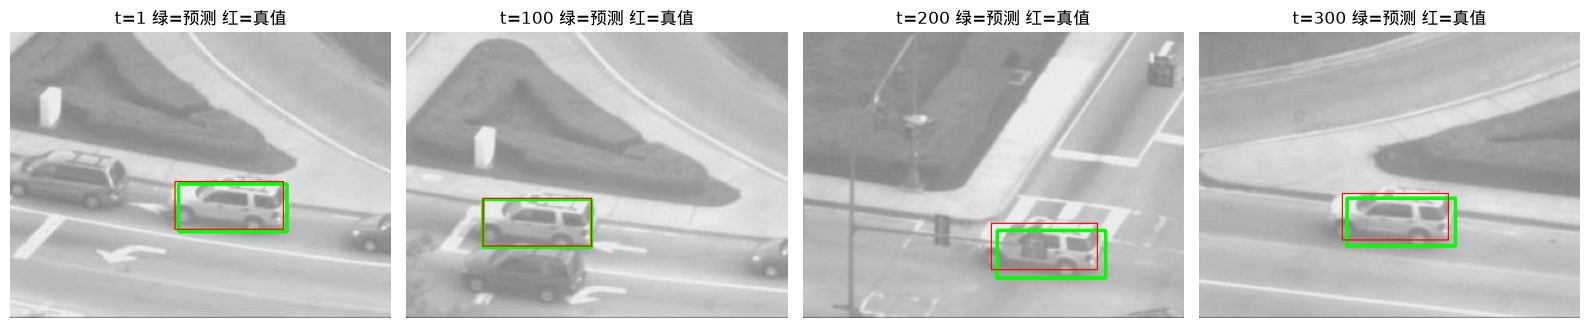

已保存: output/tracking_Suv.png


In [24]:
# ===== 8.6 真实序列验收：Suv 滚动跟踪（只做前向，不训练） =====
# 用训练好的模型在 Suv 真实帧上逐帧滚动跟踪：第 1 帧用真值框初始化，
# 之后每帧搜索 patch 以上一帧预测位置为中心（与训练窗口约定一致），
# 统计 DP@20 / Success AUC，验证"合成数据上学到的定位"能否迁移到真实序列。
# 模板 = Suv 第 1 帧掩码模板（按目标序列单独取，避免误用其他目标）。
seq_name = "Suv"
seq = sequences[seq_name]
tracker = SiameseTracker(
    make_alexnet_encoder(ALEXNET_WEIGHTS, device,
                         keep_pool2=False, keep_pool3=False),
    rnn_type=BASELINE_CONFIG["rnn_type"],
    hidden_size=BASELINE_CONFIG["hidden_size"],
    num_layers=BASELINE_CONFIG["num_layers"],
    dropout=BASELINE_CONFIG["dropout"],
    desc_channels=BASELINE_CONFIG["desc_channels"],
    finetune_encoder=BASELINE_CONFIG["finetune_encoder"],
    map_temperature=BASELINE_CONFIG["map_temperature"],
).to(device)
load_tracker(tracker, output_dir / "tracker_baseline_gru_suv.pt", device)
tracker.eval()

region_size = context_crop_size(seq.get_gt(0))
seq_search_scale = 255.0 / region_size
with torch.no_grad():
    box = seq.get_gt(0).astype(np.float32).copy()
    preds = [box.copy()]
    state = None
    template = make_masked_template(seq)[0].unsqueeze(0).to(device)
    for t in range(1, seq.num_frames):
        center = box[:2] + box[2:] / 2.0
        patch = crop_centered(seq.get_frame(t), center, region_size, (255, 255))
        prev_state = state
        d, candidate_state, conf = tracker.step(
            template, patch_to_tensor(patch).unsqueeze(0).to(device), state,
            search_scale=seq_search_scale)
        conf_value = float(conf[0, 0].cpu().item())
        if conf_value >= BASELINE_CONFIG["confidence_threshold"]:
            d = d[0].cpu().numpy()
            max_step = max(4.0, BASELINE_CONFIG["max_step_factor"] *
                           float(min(box[2:])))
            norm = float(np.linalg.norm(d))
            if norm > max_step:
                d *= max_step / max(norm, 1e-6)
            state = candidate_state
        else:
            d = np.zeros(2, dtype=np.float32)
            state = prev_state
        center = center + d
        box = np.array([center[0] - box[2] / 2, center[1] - box[3] / 2,
                        box[2], box[3]])
        preds.append(box.copy())

preds = np.array(preds, dtype=np.float32)
gts = seq.gt.astype(np.float32)
res = evaluate_sequence(preds, gts)
dist = center_distance(preds, gts)
stay = center_distance(np.tile(gts[0], (len(gts), 1)), gts)
print(f"{seq_name} 滚动跟踪: DP@20px = {res['dp']:.3f} | "
      f"Success AUC = {res['auc']:.3f} | 平均中心误差 = {dist.mean():.1f} px")
print(f"对照（停在初始位置不动）: 平均中心误差 = {stay.mean():.1f} px")

# 可视化: 第 1/100/200/300 帧（绿=预测，红=真值）
output_dir = Path("output")
output_dir.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, t in zip(axes, [1, 100, 200, 300]):
    img = draw_box(seq.get_frame(t), preds[t], (0, 255, 0), 2)
    img = draw_box(img, seq.get_gt(t), (255, 0, 0), 1)
    ax.imshow(img)
    ax.set_title(f"t={t} 绿=预测 红=真值")
    ax.axis("off")
plt.tight_layout()
save_path = output_dir / f"tracking_{seq_name}.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("已保存:", save_path)


### 9.评估：多序列滚动跟踪 + Precision/Success 图

* 评测协议（OTB 标准）：
  * 每序列只用**第 1 帧真值框**初始化，之后逐帧滚动跟踪（搜索 patch 以上一帧
    预测位置为中心），框尺寸保持第 1 帧大小（本实验不做尺度估计）
  * 指标：**Precision plot**（中心距 <= 阈值 的帧占比，取 DP@20px）、
    **Success plot**（IoU > 阈值 的帧占比，取曲线下面积 AUC），汇总到表格与平均曲线
  * 只统计有标注的帧（如 Freeman3 只有前 460 帧标注）
* 说明：baseline 均衡使用全部目标序列的第 1 帧；正式评测仍在真实视频上检验迁移效果；
  目标尺度明显变化（如 Bird1 鸟越飞越小）时固定尺度模板会失配，属已知限制
* 运行时间：GPU 约每 100 帧 2~4 秒（Suv 945 帧约 1 分钟）；CPU 慢约 10 倍，
  建议先用 `EVAL_SEQS` 小集合（如 `["DragonBaby"]`，113 帧）跑通再全量


特征通道 C=256, 响应图 (17, 17), rnn_in_dim=291 (soft-argmax 2 + conf 1 + desc 288)
Bird1        DP@20=0.463  AUC=0.254  中心误差=44.3px  （静止对照 DP=0.010 AUC=0.006）
Bolt2        DP@20=0.512  AUC=0.328  中心误差=36.8px  （静止对照 DP=0.143 AUC=0.101）
DragonBaby   DP@20=0.513  AUC=0.387  中心误差=71.8px  （静止对照 DP=0.230 AUC=0.256）
Fish         DP@20=0.960  AUC=0.807  中心误差=6.0px  （静止对照 DP=0.200 AUC=0.359）
Freeman3     DP@20=0.596  AUC=0.303  中心误差=55.3px  （静止对照 DP=0.137 AUC=0.058）
Human9       DP@20=0.148  AUC=0.144  中心误差=54.1px  （静止对照 DP=0.141 AUC=0.144）
Jogging-1    DP@20=0.909  AUC=0.555  中心误差=10.4px  （静止对照 DP=0.459 AUC=0.299）
Jogging-2    DP@20=0.938  AUC=0.630  中心误差=8.3px  （静止对照 DP=0.534 AUC=0.464）
Jumping      DP@20=0.597  AUC=0.391  中心误差=20.0px  （静止对照 DP=0.329 AUC=0.181）
Surfer       DP@20=0.870  AUC=0.434  中心误差=10.8px  （静止对照 DP=0.040 AUC=0.019）
Suv          DP@20=0.921  AUC=0.745  中心误差=8.2px  （静止对照 DP=0.098 AUC=0.187）

        序列  帧数  DP@20   AUC  中心误差px  静止DP  静止AUC
     Bird1 408  0.463 0.254    44.3 0.01

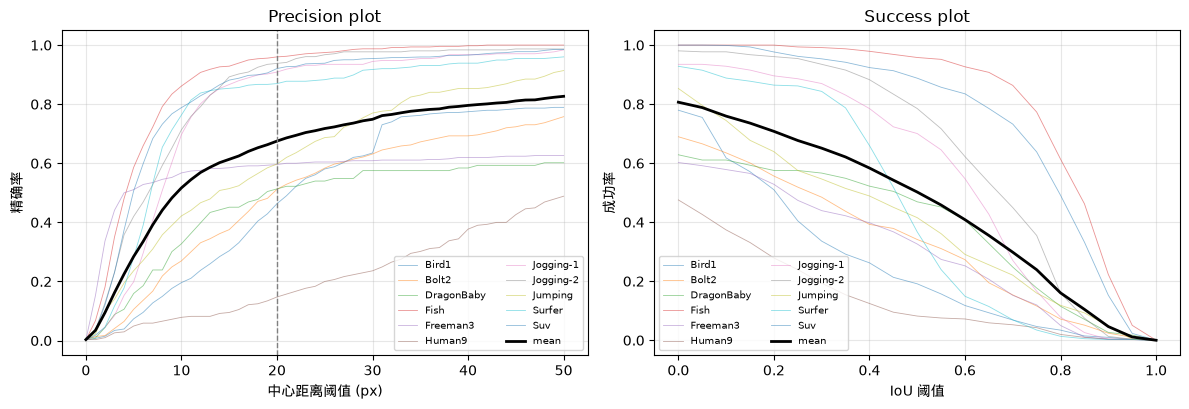

已保存: output/eval_precision_success.png


In [25]:
# ===== 9.1 多序列滚动跟踪评测（只做前向，不训练；需要先跑 8.4 训练） =====
EVAL_SEQS = sorted(sequences)  # 全部 11 条逻辑序列
# 调试时可改成例如 ["DragonBaby"]，正式结果保持全量评测


def build_baseline_tracker():
    """按 BASELINE_CONFIG 构建并加载训练好的 SiameseTracker（评测/视频共用）。"""
    model = SiameseTracker(
        make_alexnet_encoder(ALEXNET_WEIGHTS, device,
                             keep_pool2=False, keep_pool3=False),
        rnn_type=BASELINE_CONFIG["rnn_type"],
        hidden_size=BASELINE_CONFIG["hidden_size"],
        num_layers=BASELINE_CONFIG["num_layers"],
        dropout=BASELINE_CONFIG["dropout"],
        desc_channels=BASELINE_CONFIG["desc_channels"],
        finetune_encoder=BASELINE_CONFIG["finetune_encoder"],
        map_temperature=BASELINE_CONFIG["map_temperature"],
    ).to(device)
    load_tracker(model, output_dir / "tracker_baseline_gru_suv.pt", device)
    model.eval()
    return model


def robust_tracker_step(frame, center, box_size, template, tracker, state,
                        region_size, runtime_config):
    """带置信度门控、扩大搜索和位移限幅的单步闭环跟踪。"""
    def infer(region, state_in):
        patch = crop_centered(frame, center, region, (255, 255))
        d, next_state, conf = tracker.step(
            template, patch_to_tensor(patch).unsqueeze(0).to(device), state_in,
            search_scale=255.0 / region)
        return (d[0].cpu().numpy(), next_state,
                float(conf[0, 0].cpu().item()))

    d, next_state, conf = infer(region_size, state)
    threshold = float(runtime_config["confidence_threshold"])
    if conf < threshold:
        wide_region = region_size * float(runtime_config["recovery_scale"])
        wide_d, wide_state, wide_conf = infer(wide_region, state)
        if wide_conf >= float(runtime_config["recovery_threshold"]) and wide_conf > conf:
            d, next_state, conf = wide_d, wide_state, wide_conf
        else:
            # 不可信时保持位置和 RNN 状态，避免一次错误污染后续轨迹。
            return np.zeros(2, dtype=np.float32), state, conf

    max_step = max(4.0, float(runtime_config["max_step_factor"]) *
                    float(min(box_size)))
    norm = float(np.linalg.norm(d))
    if norm > max_step:
        d = d * (max_step / max(norm, 1e-6))
    return d.astype(np.float32), next_state, conf


def track_sequence(seq, template, tracker, max_frames=None):
    """第 1 帧初始化，之后使用带恢复机制的闭环跟踪。

    返回 (N,4) 预测框；跟踪循环不读取当前帧之后的图像或标注。
    """
    n = seq.gt.shape[0] if max_frames is None else min(max_frames, seq.gt.shape[0])
    region_size = context_crop_size(seq.get_gt(0))
    box = seq.get_gt(0).astype(np.float32).copy()
    preds = [box.copy()]
    state = None
    with torch.no_grad():
        for t in range(1, n):
            center = box[:2] + box[2:] / 2.0
            d, state, _ = robust_tracker_step(
                seq.get_frame(t), center, box[2:], template, tracker, state,
                region_size, BASELINE_CONFIG)
            center = center + d
            box = np.array([center[0] - box[2] / 2, center[1] - box[3] / 2,
                            box[2], box[3]], dtype=np.float32)
            preds.append(box.copy())
    return np.array(preds, dtype=np.float32)


tracker = build_baseline_tracker()
rows, curves_p, curves_s = [], [], []
for name in EVAL_SEQS:
    seq = sequences[name]
    template = make_masked_template(seq)[0].unsqueeze(0).to(device)
    preds = track_sequence(seq, template, tracker)
    gts = seq.gt[:len(preds)].astype(np.float32)
    res = evaluate_sequence(preds, gts)
    stay = evaluate_sequence(np.tile(gts[0], (len(gts), 1)), gts)
    mean_err = float(center_distance(preds, gts).mean())
    rows.append({
        "序列": name, "帧数": len(gts),
        "DP@20": round(res["dp"], 3), "AUC": round(res["auc"], 3),
        "中心误差px": round(mean_err, 1),
        "静止DP": round(stay["dp"], 3), "静止AUC": round(stay["auc"], 3),
    })
    curves_p.append(res["precision"])
    curves_s.append(res["success"])
    print(f"{name:12s} DP@20={res['dp']:.3f}  AUC={res['auc']:.3f}  "
          f"中心误差={mean_err:.1f}px  （静止对照 DP={stay['dp']:.3f} AUC={stay['auc']:.3f}）")

df = pd.DataFrame(rows)
print("\n" + df.to_string(index=False))
print(f"\n平均: DP@20 = {df['DP@20'].mean():.3f} | AUC = {df['AUC'].mean():.3f}")

# 平均 Precision/Success 曲线：细线=各序列，粗黑线=平均
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
mean_p = np.mean(curves_p, axis=0)
mean_s = np.mean(curves_s, axis=0)
for p, s, name in zip(curves_p, curves_s, EVAL_SEQS):
    axes[0].plot(res["thresholds_p"], p, lw=0.6, alpha=0.5, label=name)
    axes[1].plot(res["thresholds_s"], s, lw=0.6, alpha=0.5, label=name)
axes[0].plot(res["thresholds_p"], mean_p, "k-", lw=2, label="mean")
axes[1].plot(res["thresholds_s"], mean_s, "k-", lw=2, label="mean")
axes[0].axvline(20, ls="--", c="gray", lw=1)
axes[0].set_title("Precision plot")
axes[0].set_xlabel("中心距离阈值 (px)")
axes[0].set_ylabel("精确率")
axes[1].set_title("Success plot")
axes[1].set_xlabel("IoU 阈值")
axes[1].set_ylabel("成功率")
for ax in axes:
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
output_dir = Path("output")
output_dir.mkdir(parents=True, exist_ok=True)
save_path = output_dir / "eval_precision_success.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("已保存:", save_path)


### 9.2 推理结果视频输出（可视化）

* 把 9.1 的滚动跟踪结果逐帧叠加画框（**绿=预测，红=真值**），用 OpenCV 编码成 mp4
* `VIDEO_SEQS` 可改要渲染的序列；`VIDEO_FPS`/`VIDEO_MAX_FRAMES` 控制帧率与长度
  （建议先用 `VIDEO_MAX_FRAMES=300` 渲小片段确认效果，再全量）
* 仅用第 1 帧标注初始化，符合题目约束；视频只用于可视化，不参与指标计算


In [26]:
# ===== 9.2 推理结果视频输出（只做前向，不训练；需要先跑 8.4 训练） =====
VIDEO_SEQS = sorted(sequences)  # 全部 11 条逻辑序列
VIDEO_FPS = 20
VIDEO_MAX_FRAMES = None   # None=全部帧；可设 300 先渲小片段
VIDEO_OUT_DIR = output_dir


def render_tracking_video(seq_name, tracker, fps=20, max_frames=None):
    """滚动跟踪 + 逐帧画框，写入 mp4（绿=预测框，红=真值框，左上角=帧号）。"""
    seq = sequences[seq_name]
    template = make_masked_template(seq)[0].unsqueeze(0).to(device)
    region_size = context_crop_size(seq.get_gt(0))
    W, H = seq.size
    out_path = VIDEO_OUT_DIR / f"tracking_{seq_name}.mp4"
    writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"),
                             fps, (W, H))
    if not writer.isOpened():
        raise RuntimeError(f"VideoWriter 打开失败: {out_path}（检查 mp4v 编码器）")
    n = seq.num_frames if max_frames is None else min(max_frames, seq.num_frames)
    box = seq.get_gt(0).astype(np.float32).copy()
    state = None
    for t in range(n):
        frame = seq.get_frame(t)
        if t > 0:
            center = box[:2] + box[2:] / 2.0
            d, state, _ = robust_tracker_step(
                frame, center, box[2:], template, tracker, state,
                region_size, BASELINE_CONFIG)
            center = center + d
            box = np.array([center[0] - box[2] / 2, center[1] - box[3] / 2,
                            box[2], box[3]])
        vis = draw_box(frame, box, (0, 255, 0), 2)
        gt = seq.get_gt(t)
        if gt is not None:
            vis = draw_box(vis, gt, (255, 0, 0), 1)
        vis = cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)
        cv2.putText(vis, f"{seq_name} t={t + 1}", (10, 26),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        writer.write(vis)
        if (t + 1) % 200 == 0:
            print(f"  {seq_name}: 已渲染 {t + 1}/{n} 帧")
    writer.release()
    print(f"已保存: {out_path.resolve()}（{n} 帧, {fps} fps）")


tracker = build_baseline_tracker()
for name in VIDEO_SEQS:
    render_tracking_video(name, tracker, fps=VIDEO_FPS, max_frames=VIDEO_MAX_FRAMES)


特征通道 C=256, 响应图 (17, 17), rnn_in_dim=291 (soft-argmax 2 + conf 1 + desc 288)
  Bird1: 已渲染 200/408 帧
  Bird1: 已渲染 400/408 帧
已保存: /home/experiments/M502019B/5-final/output/tracking_Bird1.mp4（408 帧, 20 fps）
  Bolt2: 已渲染 200/293 帧
已保存: /home/experiments/M502019B/5-final/output/tracking_Bolt2.mp4（293 帧, 20 fps）
已保存: /home/experiments/M502019B/5-final/output/tracking_DragonBaby.mp4（113 帧, 20 fps）
  Fish: 已渲染 200/476 帧
  Fish: 已渲染 400/476 帧
已保存: /home/experiments/M502019B/5-final/output/tracking_Fish.mp4（476 帧, 20 fps）
  Freeman3: 已渲染 200/474 帧
  Freeman3: 已渲染 400/474 帧
已保存: /home/experiments/M502019B/5-final/output/tracking_Freeman3.mp4（474 帧, 20 fps）
  Human9: 已渲染 200/305 帧
已保存: /home/experiments/M502019B/5-final/output/tracking_Human9.mp4（305 帧, 20 fps）
  Jogging-1: 已渲染 200/307 帧
已保存: /home/experiments/M502019B/5-final/output/tracking_Jogging-1.mp4（307 帧, 20 fps）
  Jogging-2: 已渲染 200/307 帧
已保存: /home/experiments/M502019B/5-final/output/tracking_Jogging-2.mp4（307 帧, 20 fps）
  Jumping: 已渲染 2